In [390]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from matplotlib import cbook
import scipy.stats as stats
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
import warnings
warnings.filterwarnings('ignore')

## 1. Data Cleaning and Preparation

In [3]:
df = pd.read_csv('eBay.csv')

In [4]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:44:55 AM GMT+5:30,32,Prefer not to say,Multiple times a week,Groceries and Gourmet Food;Home and Kitchen,Sometimes,Rarely,categories,Multiple pages,5,...,Yes,Never,Yes,5,Yes,1,1,Customer service,.,819284
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,First page,5,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
2,2023/06/05 10:09:03 PM GMT+5:30,50,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Multiple times a day,categories,Multiple pages,1,...,Yes,Rarely,Sometimes,1,Sometimes,4,2,Customer service,Reducing packaging waste,432245
3,2023/06/07 5:58:12 PM GMT+5:30,6,Others,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,others,Multiple pages,1,...,No,Heavily,No,2,Yes,4,4,Product recommendations,Irrelevant product suggestions,476517
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Yes,Rarely,NaN,Multiple pages,5,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659


In [5]:
df.shape

(800, 24)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   639 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

##### Handle missing values and inconsistent formats in Product_Search_Method and other fields. 

In [7]:
df.isnull().sum()

Timestamp                                   0
age                                         0
Gender                                      0
Purchase_Frequency                          0
Purchase_Categories                         0
Personalized_Recommendation_Frequency       0
Browsing_Frequency                          0
Product_Search_Method                     161
Search_Result_Exploration                   0
Customer_Reviews_Importance                 0
Add_to_Cart_Browsing                        0
Cart_Completion_Frequency                   0
Cart_Abandonment_Factors                    0
Saveforlater_Frequency                      0
Review_Left                                 0
Review_Reliability                          0
Review_Helpfulness                          0
Personalized_Recommendation_Frequency       0
Recommendation_Helpfulness                  0
Rating_Accuracy                             0
Shopping_Satisfaction                       0
Service_Appreciation              

##### Product_Search_Method has 161 null values

In [8]:
# To check for unique values
df['Product_Search_Method'].unique()

array(['categories', nan, 'others', 'Keyword', 'Filter'], dtype=object)

In [9]:
mode_value = df['Product_Search_Method'].mode()[0]

In [10]:
# Replace null values with mode value
df['Product_Search_Method'] = df['Product_Search_Method'].fillna(mode_value)

In [11]:
# To recheck if nulls got replaced
df['Product_Search_Method'].unique() 

array(['categories', 'Keyword', 'others', 'Filter'], dtype=object)

##### Remove duplicate or inconsistent survey responses

In [12]:
df['Service_Appreciation'].value_counts()

Service_Appreciation
User-friendly website/app interface    101
Customer service                       100
Wide product selection                  98
.                                       91
Customer service                        87
Product recommendations                 84
All the above                           82
Quick delivery                          82
Competitive prices                      75
Name: count, dtype: int64

##### 91 records have a response as ".". This needs to be replaced with mode value

In [13]:
mode_value = df['Service_Appreciation'].mode()[0]

df.loc[df['Service_Appreciation'] == '.', 'Service_Appreciation'] = mode_value

In [14]:
mode_value = df['Improvement_Areas'].mode()[0]

df.loc[df['Improvement_Areas'] == '.', 'Improvement_Areas'] = mode_value

##### Removing unnecessary columns: Timestamp and transaction

In [15]:
df = df.drop(['Timestamp', 'transaction'], axis=1)

##### Rename duplicate or misformatted columns (e.g., remove trailing spaces in Rating_Accuracy)

In [16]:
# Trim leading and trailing spaces from all column names
df.columns = df.columns.str.strip()

In [17]:
# Copy the first occurance of Personalized_Recommendation_Frequency before deleting it from the dataframe
pd_personalized_recommendation_frequency = df.iloc[:, 4]

###### Personalized_Recommendation_Frequency is appearing twice. Hence dropping it

In [18]:
# Drop the column Personalized_Recommendation_Frequency as it is occuring twice

df = df.drop('Personalized_Recommendation_Frequency', axis=1)

In [19]:
# Putting back Personalized_Recommendation_Frequency which was stored in a pandas series
df['Personalized_Recommendation_Frequency'] = pd_personalized_recommendation_frequency

##### Convert numerical rating columns (e.g., Customer_Reviews_Importance,  Shopping_Satisfaction) to appropriate numeric types for analysis.
* No action taken

In [20]:
# Drop the columns: Improvement_Areas
df = df.drop(['Improvement_Areas'], axis=1)

## Task 2: Descriptive Behavior Analysis

#### Summarize customer demographics (age, gender distribution)

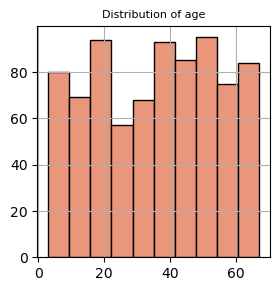

In [370]:
df['age'].hist(color='darksalmon', edgecolor='black', figsize=(3, 3))
plt.title('Distribution of age', fontsize=8)
plt.show()

In [23]:
# Extract statistics 
stats = cbook.boxplot_stats(df['age'])[0]

min_val = stats['whislo']
q1_val = round(stats['q1'],2)
median_val = round(stats['med'],2)
q3_val = round(stats['q3'],2)
max_val = stats['whishi']

print(f"Min value is: {min_val}")
print(f"Q1 value is: {q1_val}")
print(f"Median value is: {median_val}")
print(f"Q3 value is: {q3_val}")
print(f"Max value is: {max_val}")

Min value is: 3
Q1 value is: 19.0
Median value is: 37.0
Q3 value is: 52.0
Max value is: 67


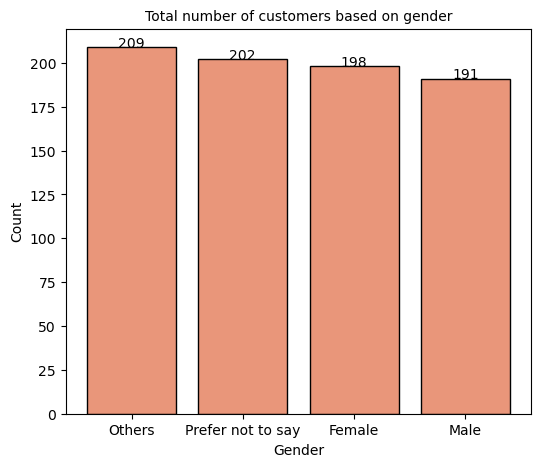

In [371]:
gender_count = df['Gender'].value_counts().reset_index()

# Create the bar chart for Gender
plt.rcParams["figure.figsize"] = (6, 5)
plt.bar(gender_count['Gender'], gender_count['count'], color='darksalmon', edgecolor= 'black')

labels  = gender_count['count']

# Adding annotations
for i, value in enumerate(labels):
    plt.text(i, value, round(value), ha='center')

# Add labels and a title
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Total number of customers based on gender', fontsize=10)

# Display the plot
plt.show()    

#### Analyze overall purchase frequency and most popular product categories

In [26]:
purchase_freq = df['Purchase_Frequency'].value_counts().reset_index()

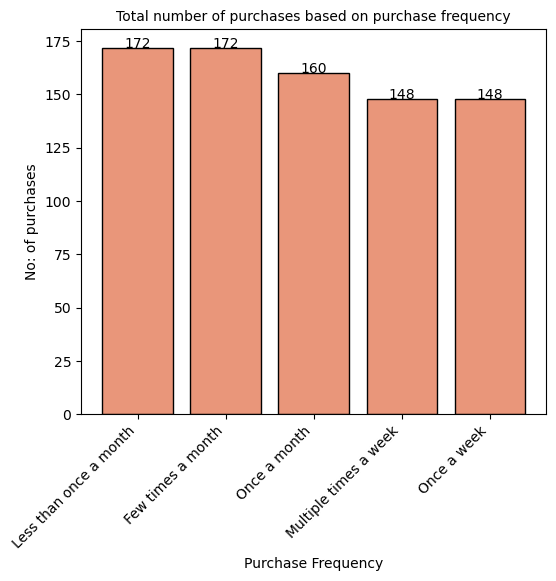

In [372]:
# Create the bar chart for Purchase Frequency
plt.rcParams["figure.figsize"] = (6, 5)
plt.bar(purchase_freq['Purchase_Frequency'], purchase_freq['count'], color='darksalmon', edgecolor='black')

labels  = purchase_freq['count']

# Adding annotations
for i, value in enumerate(labels):
    plt.text(i, value, round(value), ha='center')

# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45, ha='right')    

# Add labels and a title
plt.xlabel('Purchase Frequency')
plt.ylabel('No: of purchases')
plt.title('Total number of purchases based on purchase frequency', fontsize=10)

# Display the plot
plt.show()

##### Most people are purchasing few times a month or less than once a month. 

In [28]:
# Split Product category based on delimiter (;) and find unique values

purchase_categories = list(df['Purchase_Categories'].unique())

purchase_categories_unique = []

for each in purchase_categories:
    items = each.split(";")
    #print(items)
    for item in items:
        if item not in purchase_categories_unique:
            purchase_categories_unique.append(item)

In [29]:
num_rows = df.shape[0]
num_cols = 5
pd_dummies = np.zeros(shape=(num_rows, num_cols), dtype=int)

In [30]:
df_dummies = pd.DataFrame(pd_dummies, columns=purchase_categories_unique)
df_dummies.head()

,Groceries and Gourmet Food,Home and Kitchen,Beauty and Personal Care,Clothing and Fashion,others
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


In [31]:
df_dummies.shape

(800, 5)

In [32]:
df.shape

(800, 20)

In [33]:
# Create a seperate dataframe to store all the purchase categories
df_purchase_categories = pd.concat([df['Purchase_Categories'], df_dummies], axis=1)
df_purchase_categories.head()

,Purchase_Categories,Groceries and Gourmet Food,Home and Kitchen,Beauty and Personal Care,Clothing and Fashion,others
0,Groceries and Gourmet Food;Home and Kitchen,0,0,0,0,0
1,Groceries and Gourmet Food;Beauty and Personal...,0,0,0,0,0
2,Groceries and Gourmet Food;Beauty and Personal...,0,0,0,0,0
3,Groceries and Gourmet Food;Beauty and Personal...,0,0,0,0,0
4,Groceries and Gourmet Food;Clothing and Fashion,0,0,0,0,0


In [34]:
df_purchase_categories.loc[df_purchase_categories['Purchase_Categories'].str.contains('Beauty and Personal Care'), 'Beauty and Personal Care'] = 1
df_purchase_categories.loc[df_purchase_categories['Purchase_Categories'].str.contains('Home and Kitchen'), 'Home and Kitchen'] = 1
df_purchase_categories.loc[df_purchase_categories['Purchase_Categories'].str.contains('Groceries and Gourmet Food'), 'Groceries and Gourmet Food'] = 1
df_purchase_categories.loc[df_purchase_categories['Purchase_Categories'].str.contains('Clothing and Fashion'), 'Clothing and Fashion'] = 1
df_purchase_categories.loc[df_purchase_categories['Purchase_Categories'].str.contains('others'), 'others'] = 1

In [35]:
df_purchase_categories = df_purchase_categories.drop('Purchase_Categories', axis=1)

In [36]:
df_purchase_categories.head()

,Groceries and Gourmet Food,Home and Kitchen,Beauty and Personal Care,Clothing and Fashion,others
0,1,1,0,0,0
1,1,0,1,1,1
2,1,0,1,1,0
3,1,0,1,0,0
4,1,0,0,1,0


In [37]:
df_purchase_categories.shape

(800, 5)

In [38]:
# Drop the original column Purchase_Categories as it is no longer required
df = df.drop('Purchase_Categories', axis=1)

In [383]:
df_count = df_purchase_categories[['Beauty and Personal Care', 'Home and Kitchen', 'Groceries and Gourmet Food', 'Clothing and Fashion', 'others']].sum().reset_index(name='Count')
df_count = df_count.sort_values(by='Count', ascending=False)
df_count

,index,Count
3,Clothing and Fashion,450
1,Home and Kitchen,421
0,Beauty and Personal Care,418
4,others,390
2,Groceries and Gourmet Food,366


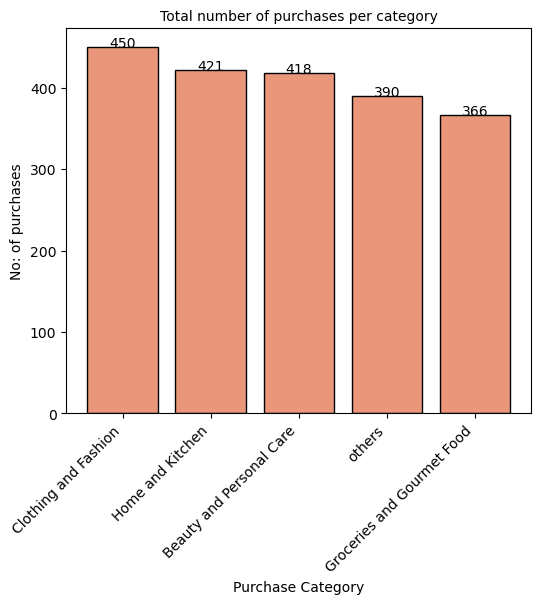

In [385]:
# Create the bar chart for Purchase Frequency
plt.rcParams["figure.figsize"] = (6, 5)
plt.bar(df_count['index'], df_count['Count'], color='darksalmon', edgecolor='black')

labels  = df_count['Count']

# Adding annotations
for i, value in enumerate(labels):
    plt.text(i, value, round(value), ha='center')

# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45, ha='right')    

# Add labels and a title
plt.xlabel('Purchase Category')
plt.ylabel('No: of purchases')
plt.title('Total number of purchases per category', fontsize=10)

# Display the plot
plt.show()

##### The most popular product categories are Clothing and Fashion, Home and Kitchen followed by Beauty and Personal Care.

### Identify top browsing methods and most common cart abandonment factors

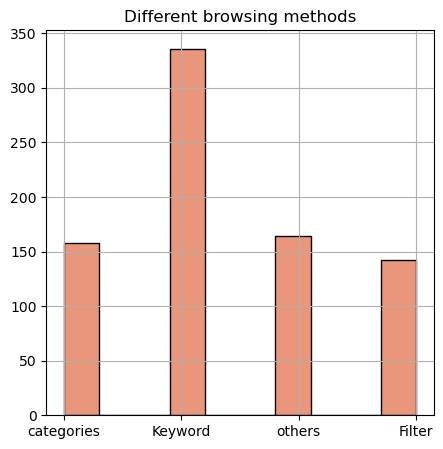

In [387]:
plt.figure(figsize=(5, 5))
df['Product_Search_Method'].hist(color='darksalmon', edgecolor='black')
plt.title('Different browsing methods')
plt.show()

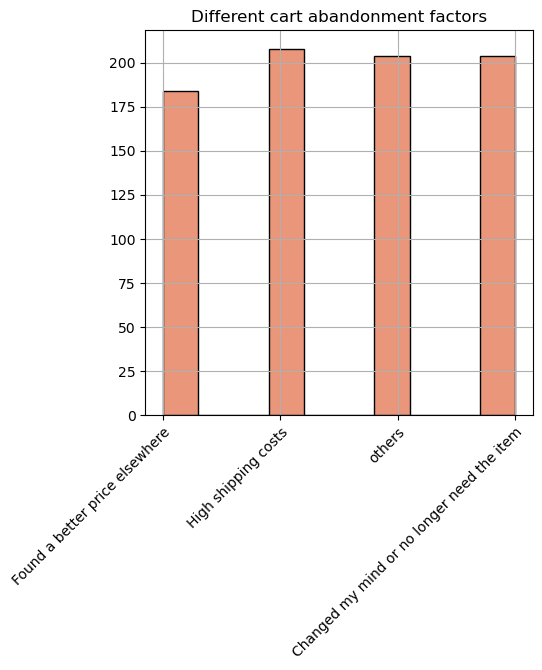

In [389]:
plt.figure(figsize=(5, 5))
df['Cart_Abandonment_Factors'].hist(color='darksalmon', edgecolor='black')
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.title('Different cart abandonment factors')
plt.show()

##### Inference:
* Top browsing method is using keyword
* High shipping cost is the main reason for cart abandonment

#### Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy

In [42]:
shopping_satisfaction_mean = df['Shopping_Satisfaction'].mean()
shopping_satisfaction_median  = df['Shopping_Satisfaction'].median()
print(f"Mean Shopping Satisfaction is: {shopping_satisfaction_mean}")
print(f"Median Shopping Satisfaction is: {shopping_satisfaction_median}")

Mean Shopping Satisfaction is: 2.86625
Median Shopping Satisfaction is: 3.0


In [43]:
rating_accuracy_mean = df['Rating_Accuracy'].mean()
rating_accuracy_median  = df['Rating_Accuracy'].median()
print(f"Mean Rating Accuracy is: {rating_accuracy_mean}")
print(f"Median Rating Accuracy is: {rating_accuracy_median}")

Mean Rating Accuracy is: 3.08625
Median Rating Accuracy is: 3.0


In [44]:
recommendation_helpfulness_mode = df['Recommendation_Helpfulness'].mode()[0]
print(f"Mode of Recommendation Helpfulness is: {recommendation_helpfulness_mode}")

Mode of Recommendation Helpfulness is: No


##### Generate summary statistics and visualizations for key behavioral variables

In [45]:
df.describe()

,age,Customer_Reviews_Importance,Rating_Accuracy,Shopping_Satisfaction
count,800.000000,800.000000,800.000000,800.000000
mean,35.730000,3.001250,3.086250,2.866250
std,18.588141,1.391463,1.420857,1.429481
min,3.000000,1.000000,1.000000,1.000000
25%,19.000000,2.000000,2.000000,2.000000
50%,37.000000,3.000000,3.000000,3.000000
75%,52.000000,4.000000,4.000000,4.000000
max,67.000000,5.000000,5.000000,5.000000


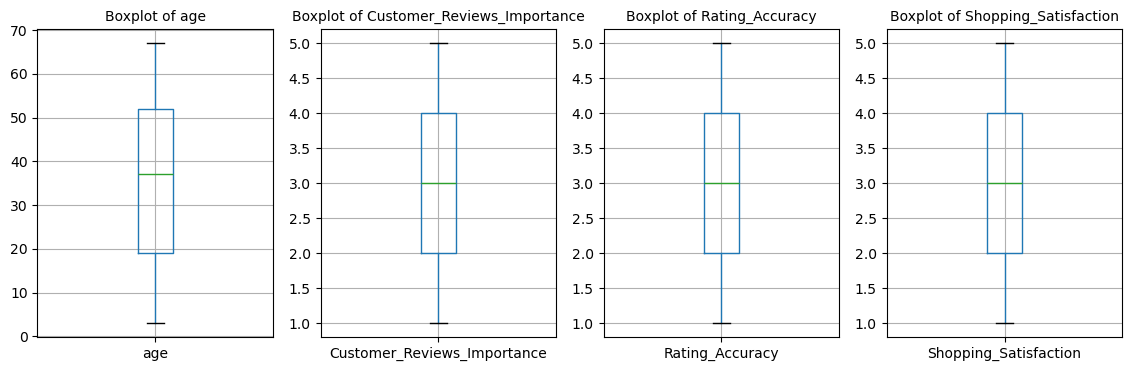

In [46]:
numerical_cols = ['age', 'Customer_Reviews_Importance', 'Rating_Accuracy', 'Shopping_Satisfaction']

rows = 1
cols = 4
plot_counter = 1

data  = df.loc[:, numerical_cols].copy()

plt.figure(figsize=(14, 4))

for col in numerical_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    data.boxplot(column=col)
    plt.title(f"Boxplot of {col}", fontsize=10)
    plot_counter += 1 # Increment the counter

##### Inference:

No outliers found in the numerical columns

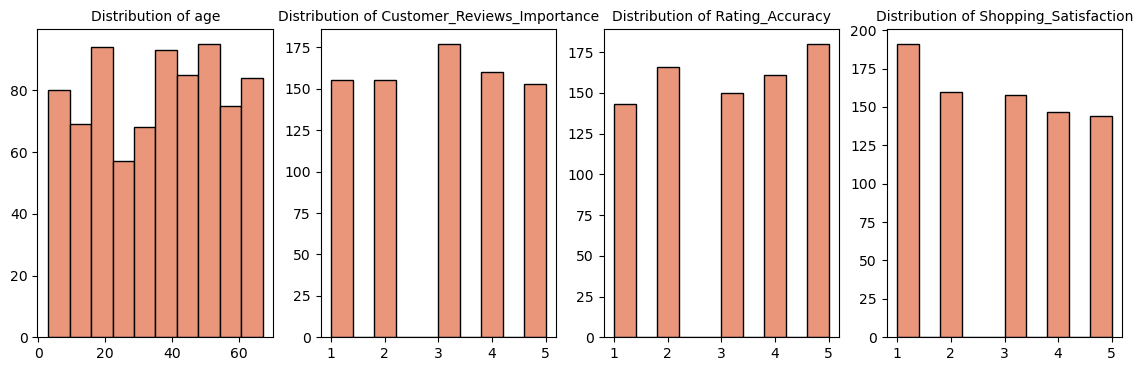

In [357]:
numerical_cols = ['age', 'Customer_Reviews_Importance', 'Rating_Accuracy', 'Shopping_Satisfaction']

rows = 1
cols = 4
plot_counter = 1

data  = df.loc[:, numerical_cols].copy()

plt.figure(figsize=(14, 4))

for col in numerical_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    plt.hist(data[col], color='darksalmon', edgecolor='black')
    plt.title(f"Distribution of {col}", fontsize=10)
    plot_counter += 1 # Increment the counter

In [48]:
categorical_cols = df.select_dtypes(include=['object']).columns.to_list()

categorical_cols.remove('Service_Appreciation')
categorical_cols.remove('Cart_Abandonment_Factors')
categorical_cols.remove('Purchase_Frequency')
categorical_cols.remove('Review_Left')
categorical_cols.remove('Review_Reliability')
categorical_cols.remove('Review_Helpfulness')
categorical_cols.remove('Recommendation_Helpfulness')
categorical_cols.remove('Cart_Completion_Frequency')
categorical_cols.remove('Saveforlater_Frequency')

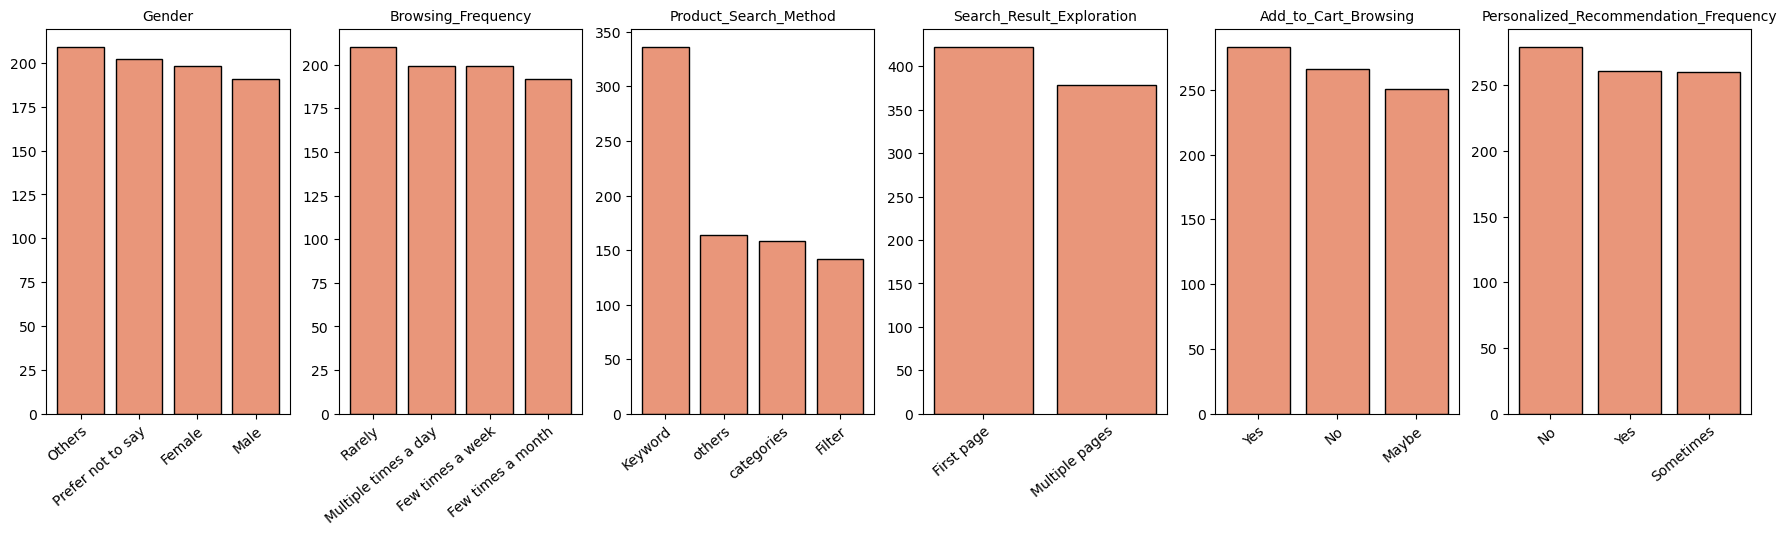

In [358]:
rows = 1
cols = 6
plot_counter = 1

data  = df.loc[:, categorical_cols].copy()

plt.figure(figsize=(22, 5))

for col in categorical_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='darksalmon', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

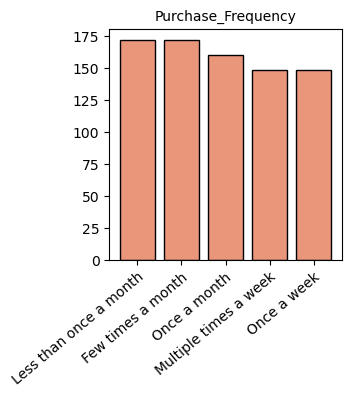

In [359]:
dt = df['Purchase_Frequency'].value_counts().reset_index(name='Count')
plt.figure(figsize=(3, 3))
plt.bar(dt['Purchase_Frequency'], dt['Count'], color='darksalmon', edgecolor='black')
plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
plt.title("Purchase_Frequency", fontsize=10)
plt.show()

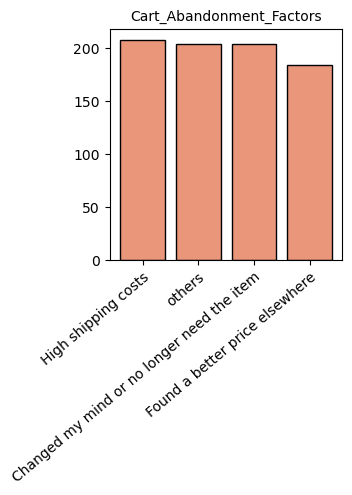

In [360]:
dt = df['Cart_Abandonment_Factors'].value_counts().reset_index(name='Count')
plt.figure(figsize=(3, 3))
plt.bar(dt['Cart_Abandonment_Factors'], dt['Count'], color='darksalmon', edgecolor='black')
plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
plt.title("Cart_Abandonment_Factors", fontsize=10)
plt.show()

##### Inference:

* Most of the users belong to "Other" gender
* Most of the users browse rarely
* Most used search method is using keyword
* Most users search only in the first page and do not explore multiple pages
* Most users add items to cart for browsing later
* Most often personalized recommendations are not shown
* Most users purchase less than once a month or a few times a month
* Most users abandon their cart due to high shipping cost

### Task 3: Customer Segmentation and Profiling

#### Segment customers based on purchase frequency and shopping satisfaction levels

##### Purchase Frequency Score
* Less than once a month: 1
* Once a month: 2
* Few times a month: 3
* Once a week: 4
* Multiple times a week: 5

In [52]:
# Give a score to users based on their Purchase_Frequency
df.loc[df['Purchase_Frequency'] == 'Less than once a month', 'Purchase_Frequency_Score'] = 1
df.loc[df['Purchase_Frequency'] == 'Once a month', 'Purchase_Frequency_Score'] = 2
df.loc[df['Purchase_Frequency'] == 'Few times a month', 'Purchase_Frequency_Score'] = 3
df.loc[df['Purchase_Frequency'] == 'Once a week', 'Purchase_Frequency_Score'] = 4
df.loc[df['Purchase_Frequency'] == 'Multiple times a week', 'Purchase_Frequency_Score'] = 5

##### Shopping Satisfaction Score:
* 1: Very Dissatisfied
* 2: Less Satisfied
* 3: Neutral
* 4: Satisfied
* 5: Very Satisfied

#### Create profiles such as: 
* Frequent Buyers: High purchase frequency, high satisfaction. 
* Occasional Shoppers: Medium frequency, moderate satisfaction. 
* At-Risk Customers: Low satisfaction or frequent cart abandonment. 

In [53]:
# Create a customer score which is a sum of Purchase_Frequency_Score and Shopping_Satisfaction
df['Customer_Shopping_Score'] = df['Purchase_Frequency_Score'] + df['Shopping_Satisfaction']

In [54]:
df['Purchase_Frequency_Score'] = df['Purchase_Frequency_Score'].astype(int)
df['Customer_Shopping_Score'] = df['Customer_Shopping_Score'].astype(int)

In [55]:
# Extract statistics 
stats = cbook.boxplot_stats(df['Customer_Shopping_Score'])[0]

min_val = stats['whislo']
q1_val = round(stats['q1'],2)
median_val = round(stats['med'],2)
q3_val = round(stats['q3'],2)
max_val = stats['whishi']

#print(f"Minimum value is: {min_val}")
print(f"Q1 value is: {q1_val}")
print(f"Median(Q2) value is: {median_val}")
print(f"Q3 value is: {q3_val}")
#print(f"Maximum value is: {max_val}")

Q1 value is: 4.0
Median(Q2) value is: 6.0
Q3 value is: 7.0


In [56]:
df.loc[df['Customer_Shopping_Score']<= q1_val, 'Customer_Segmentation'] = 'At-Risk Customers'
df.loc[(df['Customer_Shopping_Score']> q1_val) & (df['Customer_Shopping_Score']< q3_val), 'Customer_Segmentation'] = 'Occasional Shoppers'
df.loc[df['Customer_Shopping_Score']>= q3_val, 'Customer_Segmentation'] = 'Frequent Buyers'

In [57]:
df['Customer_Segmentation'].value_counts()

Customer_Segmentation
Occasional Shoppers    306
Frequent Buyers        280
At-Risk Customers      214
Name: count, dtype: int64

##### Inference:
* Frequent Buyers: 280 users
* Occasional Shoppers: 306 users
* At-Risk Customers: 214 users

Most of the users are occasional shoppers.

#### Analyze demographic or behavioral differences across these segments.

* Demographic factors: age, Gender
* Behavioural factors: Purchase_Frequency, Browsing_Frequency, Cart_Completion_Frequency, Cart_Abandonment_Factors, Saveforlater_Frequency

In [58]:
df_frequent_buyers = df[df['Customer_Segmentation'] == 'Frequent Buyers']
df_occasional_shoppers = df[df['Customer_Segmentation'] == 'Occasional Shoppers']
df_at_risk_customers = df[df['Customer_Segmentation'] == 'At-Risk Customers']

#### Frequent Buyers

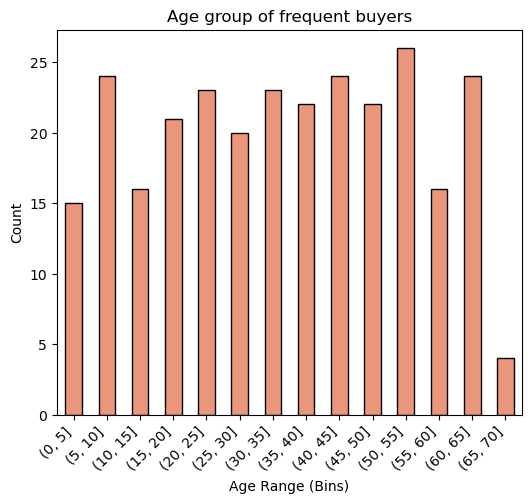

In [361]:
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
binned_counts = pd.cut(df_frequent_buyers['age'], bins=bins).value_counts().sort_index()

# 4. Plot the results as a bar chart
binned_counts.plot.bar(rot=0, title='Age group of frequent buyers', color= 'darksalmon', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Age Range (Bins)')
plt.ylabel('Count')
plt.show()

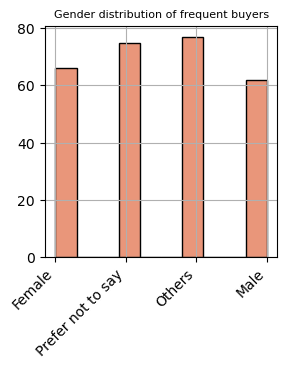

In [362]:
df_frequent_buyers['Gender'].hist(color='darksalmon', edgecolor='black', figsize=(3, 3))
plt.title('Gender distribution of frequent buyers', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.show()

In [61]:
behavioural_cols = ['Purchase_Frequency', 'Browsing_Frequency', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency']

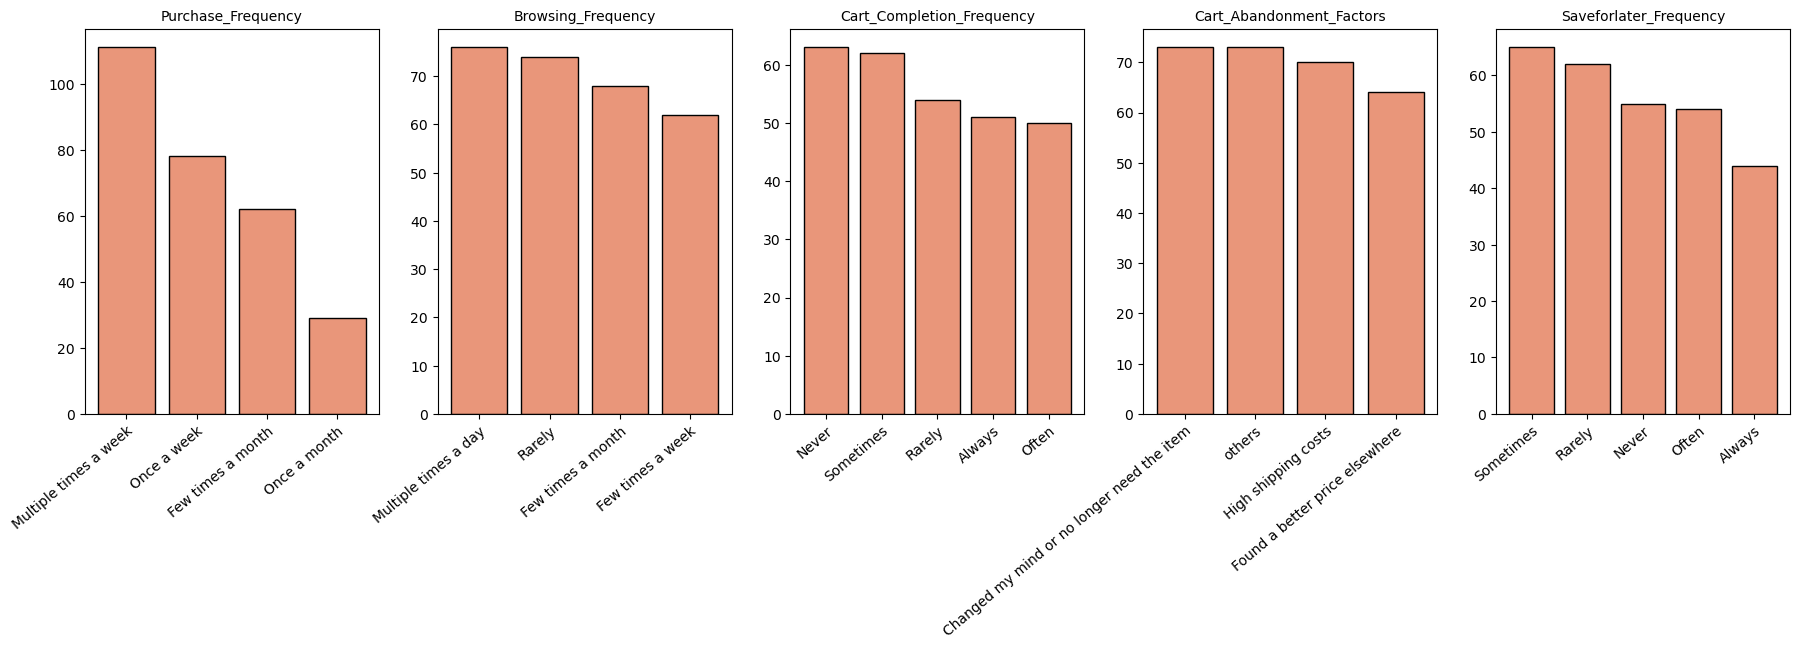

In [363]:
rows = 1
cols = 5
plot_counter = 1

data  = df_frequent_buyers.loc[:, behavioural_cols].copy()

plt.figure(figsize=(22, 5))

for col in behavioural_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='darksalmon', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

##### Profile of frequent buyers
* Most of the frequent buyers do not prefer to reveal their gender or belong to "others".
* Most of the frequent buyers are of the age group 50-55 years followed by 60-65 years.
* Most of them purchase multiple times a week.
* Most of them browse multiple times a day.
* Only some of them complete purchases from their cart.
* Most frequent reason for cart abandonment is change of mind.
* Only some of them save their cart for later.

#### Occasional Shoppers

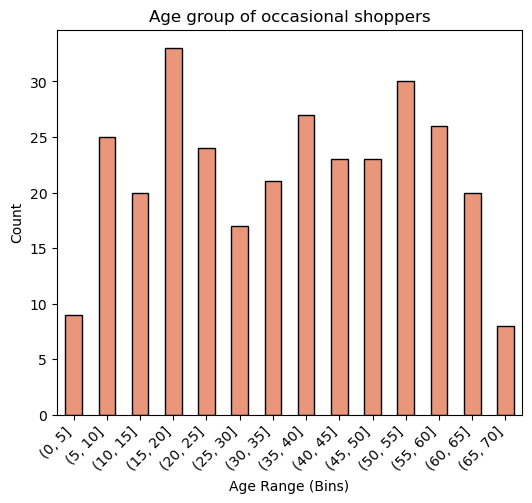

In [364]:
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
binned_counts = pd.cut(df_occasional_shoppers['age'], bins=bins).value_counts().sort_index()

# 4. Plot the results as a bar chart
binned_counts.plot.bar(rot=0, title='Age group of occasional shoppers', color= 'darksalmon', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Age Range (Bins)')
plt.ylabel('Count')
plt.show()

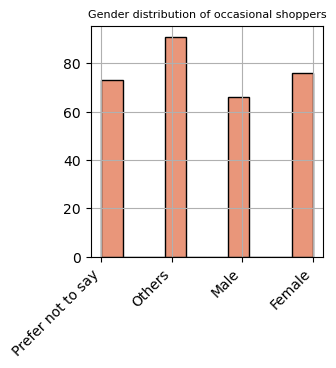

In [365]:
df_occasional_shoppers['Gender'].hist(color='darksalmon', edgecolor='black', figsize=(3, 3))
plt.title('Gender distribution of occasional shoppers', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.show()

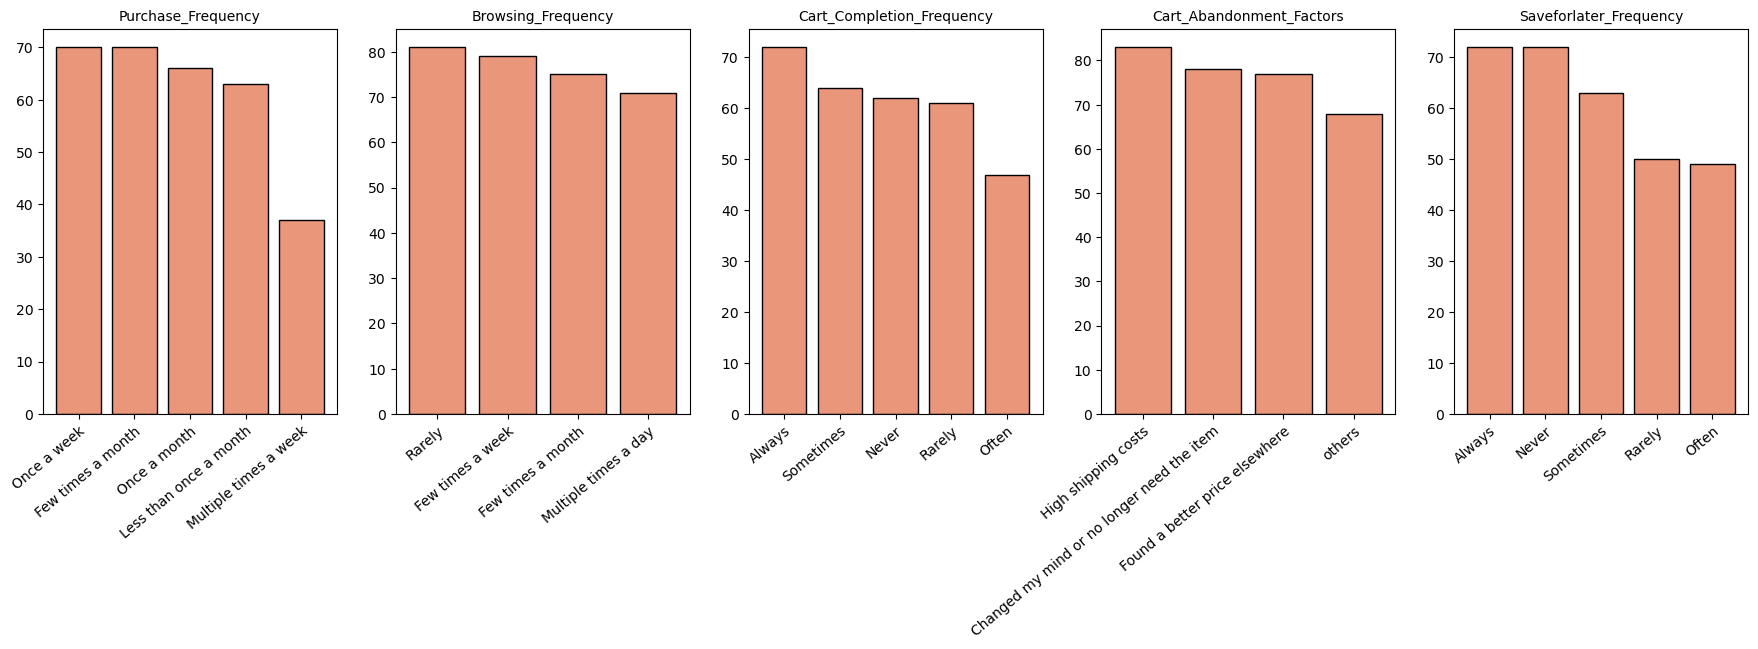

In [366]:
rows = 1
cols = 5
plot_counter = 1

data  = df_occasional_shoppers.loc[:, behavioural_cols].copy()

plt.figure(figsize=(22, 5))

for col in behavioural_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='darksalmon', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

##### Profile of occasional shoppers
* Most of the occasional shoppers belong to "others" or are females.
* Most of the occasional shoppers are of the age group 15-20 years followed by 50-55 years.
* Most of them purchase once a week.
* Most of them rarely browse or few times a week.
* Most them complete purchases from their cart.
* Most frequent reason for cart abandonment is high shipping cost.
* Most of them save their cart for later.

#### At-Risk Customers

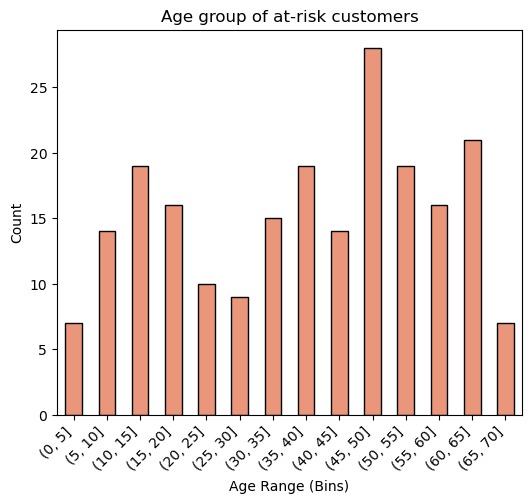

In [367]:
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
binned_counts = pd.cut(df_at_risk_customers['age'], bins=bins).value_counts().sort_index()

# 4. Plot the results as a bar chart
binned_counts.plot.bar(rot=0, title='Age group of at-risk customers', color= 'darksalmon', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Age Range (Bins)')
plt.ylabel('Count')
plt.show()

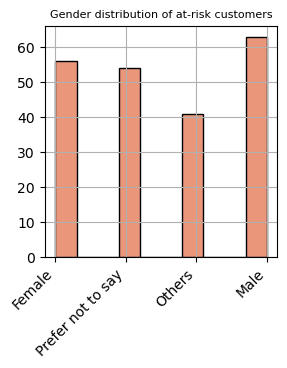

In [368]:
df_at_risk_customers['Gender'].hist(color='darksalmon', edgecolor='black', figsize=(3, 3))
plt.title('Gender distribution of at-risk customers', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.show()

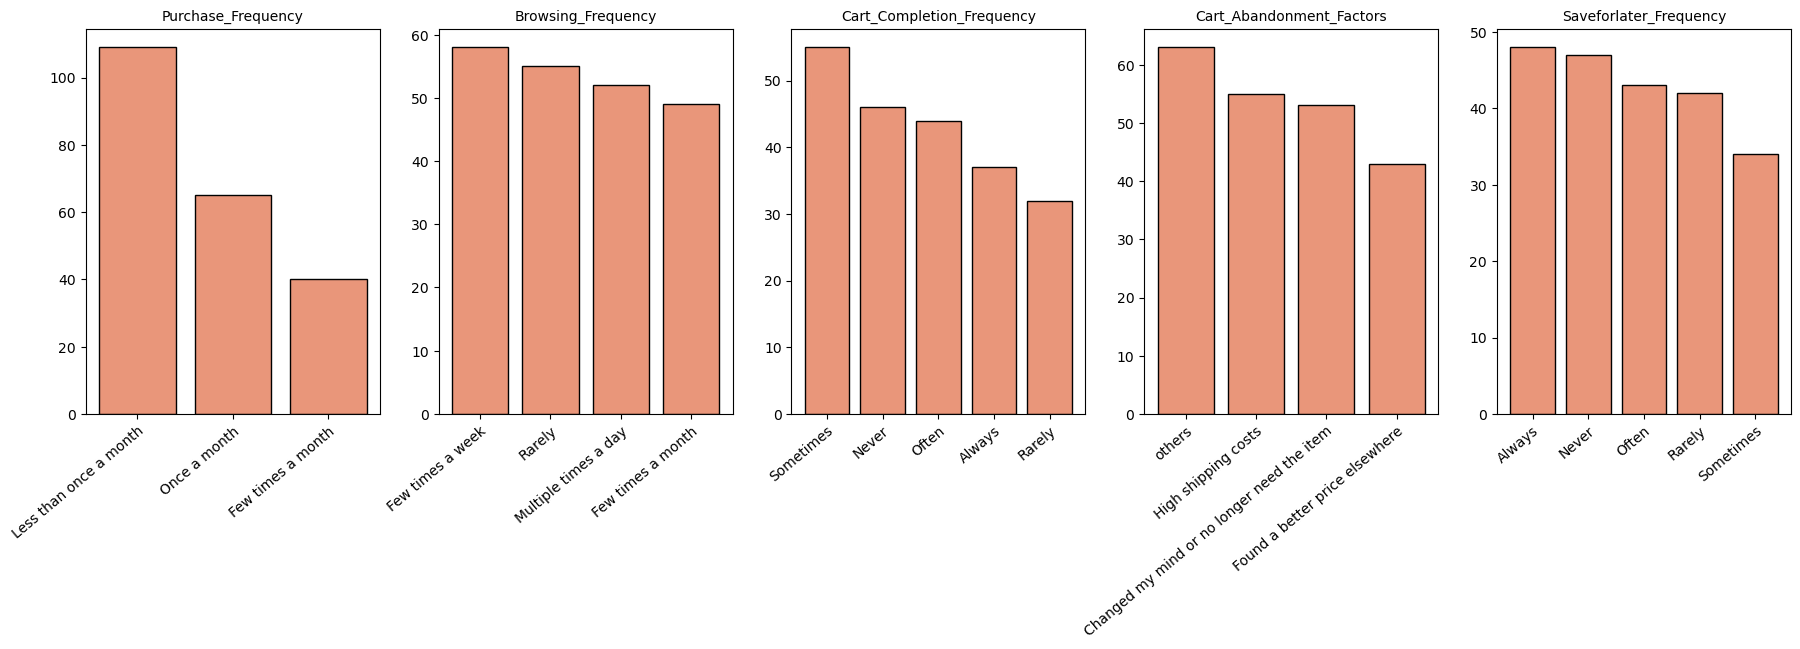

In [369]:
rows = 1
cols = 5
plot_counter = 1

data  = df_at_risk_customers.loc[:, behavioural_cols].copy()

plt.figure(figsize=(22, 5))

for col in behavioural_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='darksalmon', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

##### Profile of at-risk customers
* Most of the at-risk customers are male.
* Most of the at-risk customers are of the age group 45-50 years.
* Most of them purchase less than once a month.
* Most of them browse few times a week.
* Only sometimes they complete purchases from their cart.
* Most frequent reason for cart abandonment is not clear (other).
* Most of them save their cart for later.

### Use clustering (e.g., K-Means) for behavioral grouping based on survey responses.

In [69]:
df_final = pd.concat([df, df_purchase_categories], axis=1)

In [70]:
# Separate Numerical and Categorical Features
num_cols = df_final.select_dtypes(include=np.number).columns
cat_cols = df_final.select_dtypes(exclude=np.number).columns

In [71]:
num_cols

Index(['age', 'Customer_Reviews_Importance', 'Rating_Accuracy',
       'Shopping_Satisfaction', 'Purchase_Frequency_Score',
       'Customer_Shopping_Score', 'Groceries and Gourmet Food',
       'Home and Kitchen', 'Beauty and Personal Care', 'Clothing and Fashion',
       'others'],
      dtype='object')

In [72]:
cat_cols

Index(['Gender', 'Purchase_Frequency', 'Browsing_Frequency',
       'Product_Search_Method', 'Search_Result_Exploration',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Recommendation_Helpfulness', 'Service_Appreciation',
       'Personalized_Recommendation_Frequency', 'Customer_Segmentation'],
      dtype='object')

In [73]:
for col in cat_cols:
    # Create an instance of LabelEncoder
    le = LabelEncoder()

    # Fit and transform the 'State' column, replacing the original column
    df_final[col] = le.fit_transform(df_final[col])
    df_final[col] = df_final[col].astype(int)

In [74]:
df_final.head()

,age,Gender,Purchase_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,...,Service_Appreciation,Personalized_Recommendation_Frequency,Purchase_Frequency_Score,Customer_Shopping_Score,Customer_Segmentation,Groceries and Gourmet Food,Home and Kitchen,Beauty and Personal Care,Clothing and Fashion,others
0,32,3,2,3,2,1,5,0,1,1,...,3,1,5,6,2,1,1,0,0,0
1,47,0,2,0,1,0,5,1,4,2,...,6,0,5,9,1,1,0,1,1,1
2,50,0,3,2,2,1,1,1,3,3,...,3,1,2,4,0,1,0,1,1,0
3,6,2,3,3,3,1,1,2,2,3,...,4,0,2,6,2,1,0,1,0,0
4,61,1,4,3,1,1,5,2,0,1,...,4,2,4,6,2,1,0,0,1,0


In [75]:
# Create an instance of the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform the data
X_scaled = scaler.fit_transform(df_final)

In [76]:
# Apply PCA
# Initialize PCA with the desired number of components
pca = PCA(n_components=2)

# Fit and transform the scaled data
X_pca = pca.fit_transform(X_scaled)

WCSS
 [2954.400267229336, 1529.9520014349966, 975.3069426091421, 750.8626216842933, 606.4197802695611, 471.91495417447686, 419.31545897898917, 381.12621694863947, 343.7347554712631]


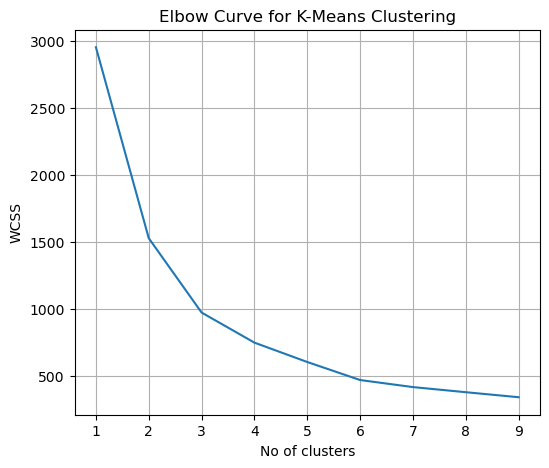

In [77]:
# wcss = within cluster sum of square
wcss = []
for i in range(1,10): 
    m = KMeans(n_clusters=i, n_init=50, max_iter=500)
    m.fit(X_pca)
    wcss.append(m.inertia_)

print('WCSS\n',wcss)
plt.plot(list(range(1,10)),wcss)
plt.xlabel('No of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Curve for K-Means Clustering')
plt.grid()
plt.show()

In [78]:
for i in range(2,10): # i = no of clusters
    m = KMeans(n_clusters=i).fit(X_pca)
    print(f'Silhoutte Score at K={i}',silhouette_score(X_pca,m.labels_))

Silhoutte Score at K=2 0.48275414123449323
Silhoutte Score at K=3 0.4196674274293223
Silhoutte Score at K=4 0.4210381821899024
Silhoutte Score at K=5 0.4054907535856282
Silhoutte Score at K=6 0.3925871749218889
Silhoutte Score at K=7 0.35999346284090405
Silhoutte Score at K=8 0.3472964779738861
Silhoutte Score at K=9 0.3303758518577055


#### Optimal number of clusters = 4

In [267]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(X_pca)
y_kmeans = kmeans.predict(X_pca)
print(y_kmeans)

[2 1 3 0 2 3 1 0 3 1 1 3 0 0 2 1 1 3 0 3 2 3 2 0 0 0 3 3 3 3 3 1 3 3 1 3 2
 2 2 3 2 2 3 3 3 3 0 1 3 3 1 1 3 0 3 0 2 0 0 0 0 2 0 1 0 3 1 3 1 2 3 0 1 1
 2 3 3 0 0 2 3 3 0 0 2 3 0 2 2 0 1 1 1 2 3 3 0 1 0 3 2 0 3 0 3 3 3 1 1 3 3
 2 0 1 2 0 3 1 2 1 0 2 0 3 3 1 1 0 2 2 0 0 2 3 1 3 2 3 0 0 3 3 0 1 0 0 0 0
 3 3 2 0 2 0 0 0 2 0 2 3 3 0 0 0 2 0 2 3 1 2 0 3 0 2 0 1 0 3 2 2 2 0 0 0 2
 3 0 1 2 1 0 0 2 1 0 0 0 2 0 3 3 3 2 3 1 2 3 2 2 2 3 1 2 2 1 2 2 2 1 2 3 3
 2 0 0 0 1 2 0 2 3 3 1 0 2 3 2 3 1 1 3 1 2 0 2 0 3 2 2 2 2 2 3 0 0 3 3 0 0
 0 2 0 0 3 1 2 3 3 3 1 3 0 0 0 3 2 0 0 2 3 2 0 3 3 1 1 0 2 0 3 1 3 3 3 0 1
 2 3 0 2 3 0 3 2 2 3 3 1 0 0 2 2 0 3 0 3 3 3 0 2 2 3 2 1 2 3 0 0 1 2 1 2 2
 3 0 2 2 3 3 2 3 2 0 3 3 2 1 2 2 0 1 0 1 2 1 3 0 3 0 1 2 0 3 3 0 3 2 0 0 3
 2 3 3 3 2 3 2 0 1 2 1 2 3 2 2 0 0 2 3 1 3 3 1 0 0 3 0 0 1 0 2 0 1 2 0 0 0
 1 3 3 1 2 0 3 0 2 1 0 1 3 2 2 2 0 1 1 0 3 0 0 0 0 2 2 0 2 3 1 2 1 3 3 3 3
 2 1 3 0 0 1 3 0 2 2 2 0 0 2 0 1 2 1 0 3 0 3 0 0 2 0 0 0 0 3 0 2 3 3 1 2 3
 2 1 0 3 0 1 0 1 2 2 1 0 

In [268]:
from collections import Counter

c1 = Counter(y_kmeans)
print(c1)

Counter({np.int32(0): 242, np.int32(2): 220, np.int32(3): 211, np.int32(1): 127})


In [269]:
# Get the coordinates of the cluster centers
centers = kmeans.cluster_centers_
print(centers)

[[ 0.26461149  1.09308921]
 [ 1.93565256  0.17279328]
 [ 0.70557903 -1.11821568]
 [-2.2042239  -0.19177671]]


In [270]:
df_final['Cluster'] = y_kmeans

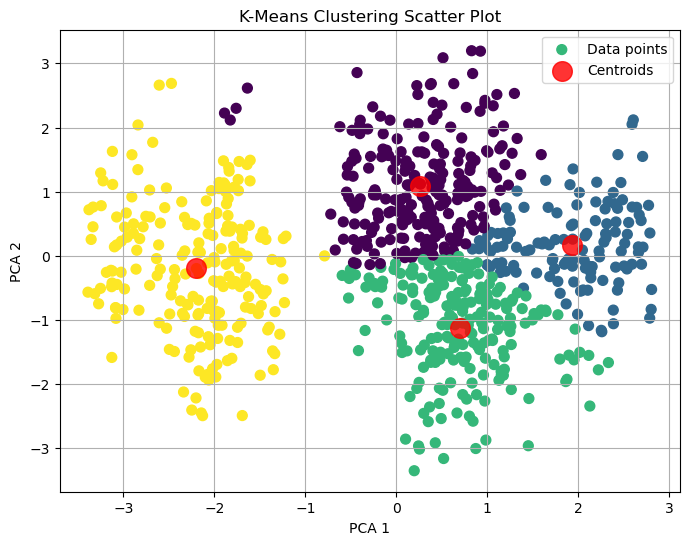

In [271]:
# Create the Scatter Plot
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, s=50, cmap='viridis', label='Data points')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='o', label='Centroids', alpha=0.8)
plt.title('K-Means Clustering Scatter Plot')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

#### Characteristics of the 4 clusters formed

In [272]:
df['Cluster'] = y_kmeans

In [273]:
cluster0 = df[df['Cluster'] == 0]
cluster1 = df[df['Cluster'] == 1]
cluster2 = df[df['Cluster'] == 2]
cluster3 = df[df['Cluster'] == 3]

In [149]:
# Separate Numerical and Categorical Features
num_cols = list(df.select_dtypes(include=np.number).columns)
cat_cols = list(df.select_dtypes(exclude=np.number).columns)

In [274]:
num_cols.remove('age')
num_cols.remove('Cluster')
num_cols.remove('Customer_Shopping_Score')

ValueError: list.remove(x): x not in list

In [275]:
num_cols

['Customer_Reviews_Importance',
 'Rating_Accuracy',
 'Shopping_Satisfaction',
 'Purchase_Frequency_Score']

In [152]:
cat_cols.remove('Gender')
cat_cols.remove('Review_Left')
cat_cols.remove('Review_Reliability')
cat_cols.remove('Review_Helpfulness')
cat_cols.remove('Recommendation_Helpfulness')
cat_cols.remove('Service_Appreciation')
cat_cols.remove('Personalized_Recommendation_Frequency')
cat_cols.remove('Product_Search_Method')
cat_cols.remove('Cart_Abandonment_Factors')
cat_cols.remove('Search_Result_Exploration')
cat_cols.remove('Add_to_Cart_Browsing')

In [276]:
cat_cols

['Purchase_Frequency',
 'Browsing_Frequency',
 'Cart_Completion_Frequency',
 'Saveforlater_Frequency',
 'Customer_Segmentation']

#### Cluster 0 pattern and behaviour

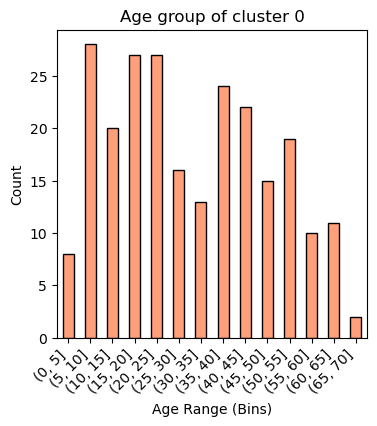

In [313]:
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
binned_counts = pd.cut(cluster0['age'], bins=bins).value_counts().sort_index()

# 4. Plot the results as a bar chart
binned_counts.plot.bar(rot=0, title='Age group of cluster 0', color= 'lightsalmon', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Age Range (Bins)')
plt.ylabel('Count')
plt.show()

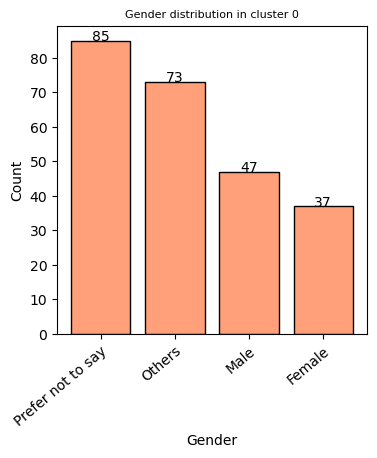

In [314]:
gender_count = cluster0['Gender'].value_counts().reset_index()

# Create the bar chart for Gender
plt.rcParams["figure.figsize"] = (4, 4)
plt.bar(gender_count['Gender'], gender_count['count'], color='lightsalmon', edgecolor= 'black')

labels  = gender_count['count']

# Adding annotations
for i, value in enumerate(labels):
    plt.text(i, value, round(value), ha='center')

plt.xticks(rotation=40, ha='right', rotation_mode='anchor')

# Add labels and a title
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender distribution in cluster 0', fontsize=8)

# Display the plot
plt.show()    

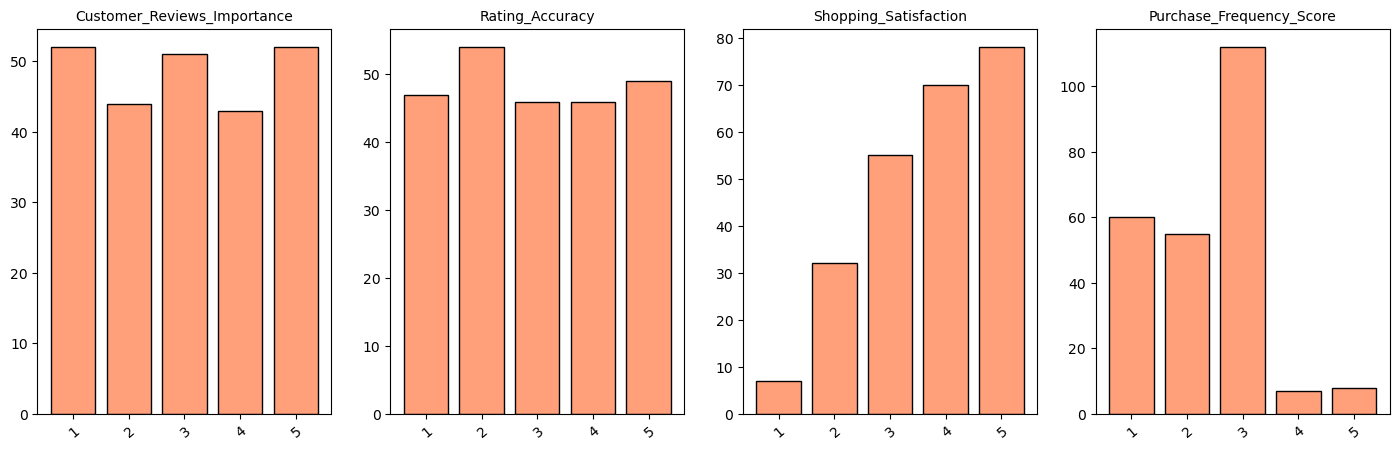

In [315]:
rows = 1
cols = 5
plot_counter = 1

data  = cluster0.loc[:, num_cols].copy()

plt.figure(figsize=(22, 5))

for col in num_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='lightsalmon', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

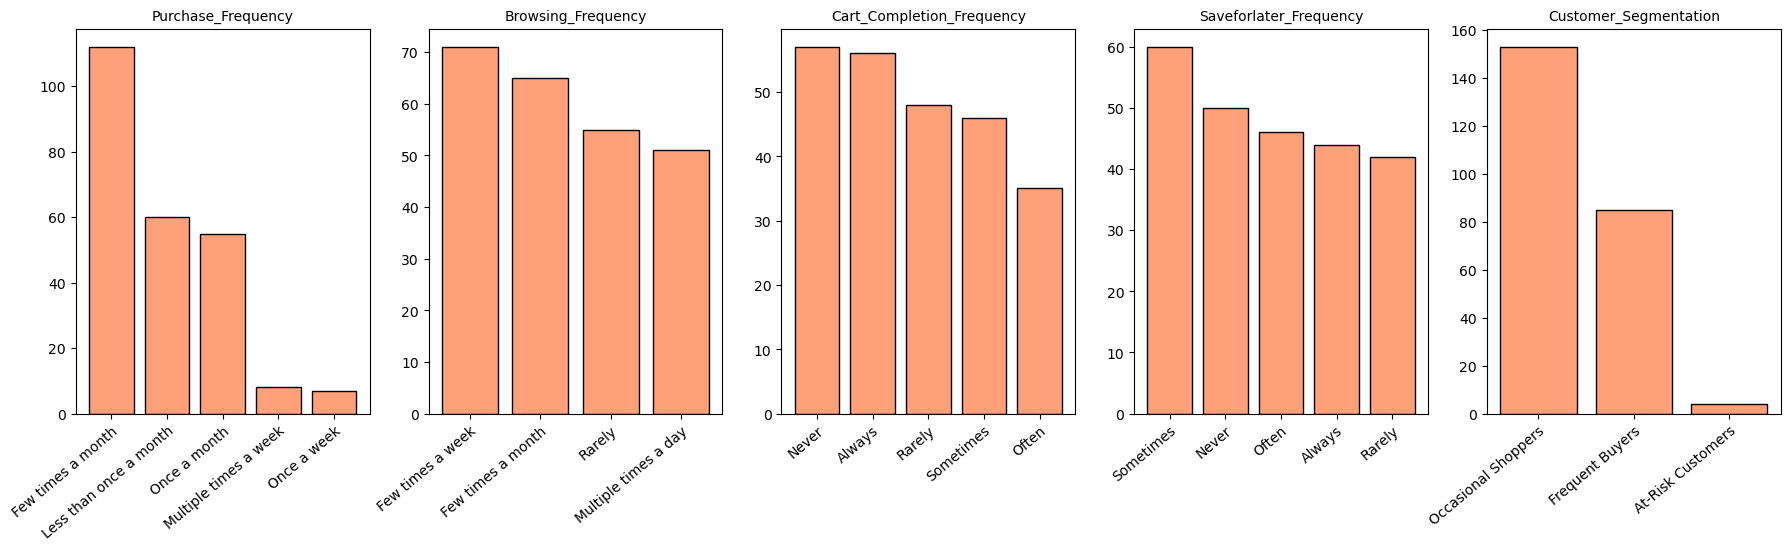

In [316]:
rows = 1
cols = 5
plot_counter = 1

data  = cluster0.loc[:, cat_cols].copy()

plt.figure(figsize=(22, 5))

for col in cat_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='lightsalmon', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

##### Inference on Cluster 0:
* Cluster 0 is predominantly young group with age groups: 5-10, 15-20 and 20-25 years old 
* Most of the users prefer not to say their gender
* Very high shopping satisfaction
* Do purchase once a week or multiple times a week
* Mixed browsing frequency
* Mixed cart completion frequency
* Mixed save for later frequency
* A mix of occasional buyers or frequent buyers
* This is a loyal and strong customer segment for Ebay. This segment can be converted to a premium segment using better personalized recommendations.

#### Cluster 1 pattern and behaviour

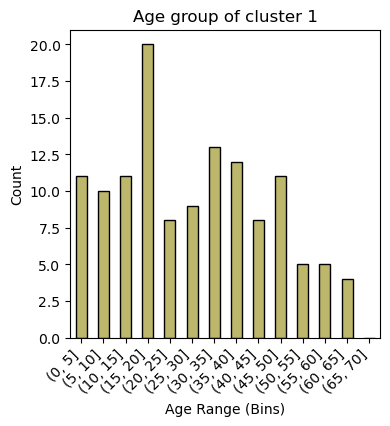

In [309]:
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
binned_counts = pd.cut(cluster1['age'], bins=bins).value_counts().sort_index()

# 4. Plot the results as a bar chart
binned_counts.plot.bar(rot=0, title='Age group of cluster 1', color= 'darkkhaki', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Age Range (Bins)')
plt.ylabel('Count')
plt.show()

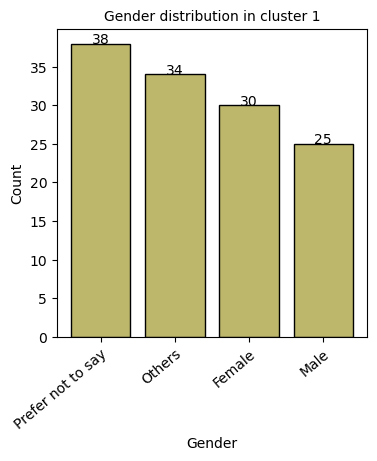

In [310]:
gender_count = cluster1['Gender'].value_counts().reset_index()

# Create the bar chart for Gender
plt.rcParams["figure.figsize"] = (4, 4)
plt.bar(gender_count['Gender'], gender_count['count'], color='darkkhaki', edgecolor= 'black')

labels  = gender_count['count']

# Adding annotations
for i, value in enumerate(labels):
    plt.text(i, value, round(value), ha='center')

plt.xticks(rotation=40, ha='right', rotation_mode='anchor')

# Add labels and a title
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender distribution in cluster 1', fontsize=10)

# Display the plot
plt.show()    

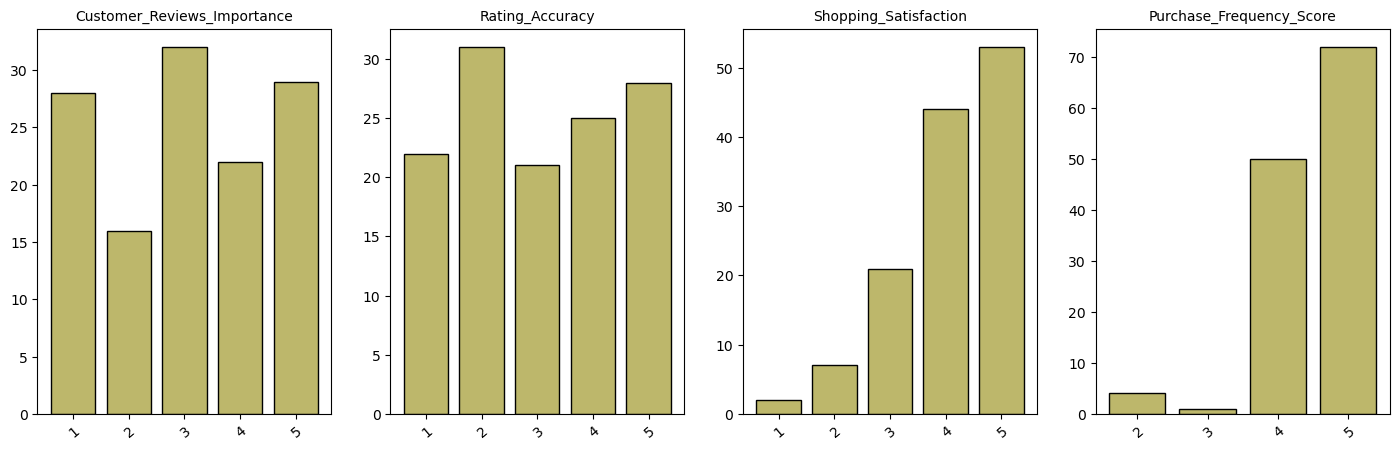

In [311]:
rows = 1
cols = 5
plot_counter = 1

data  = cluster1.loc[:, num_cols].copy()

plt.figure(figsize=(22, 5))

for col in num_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='darkkhaki', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

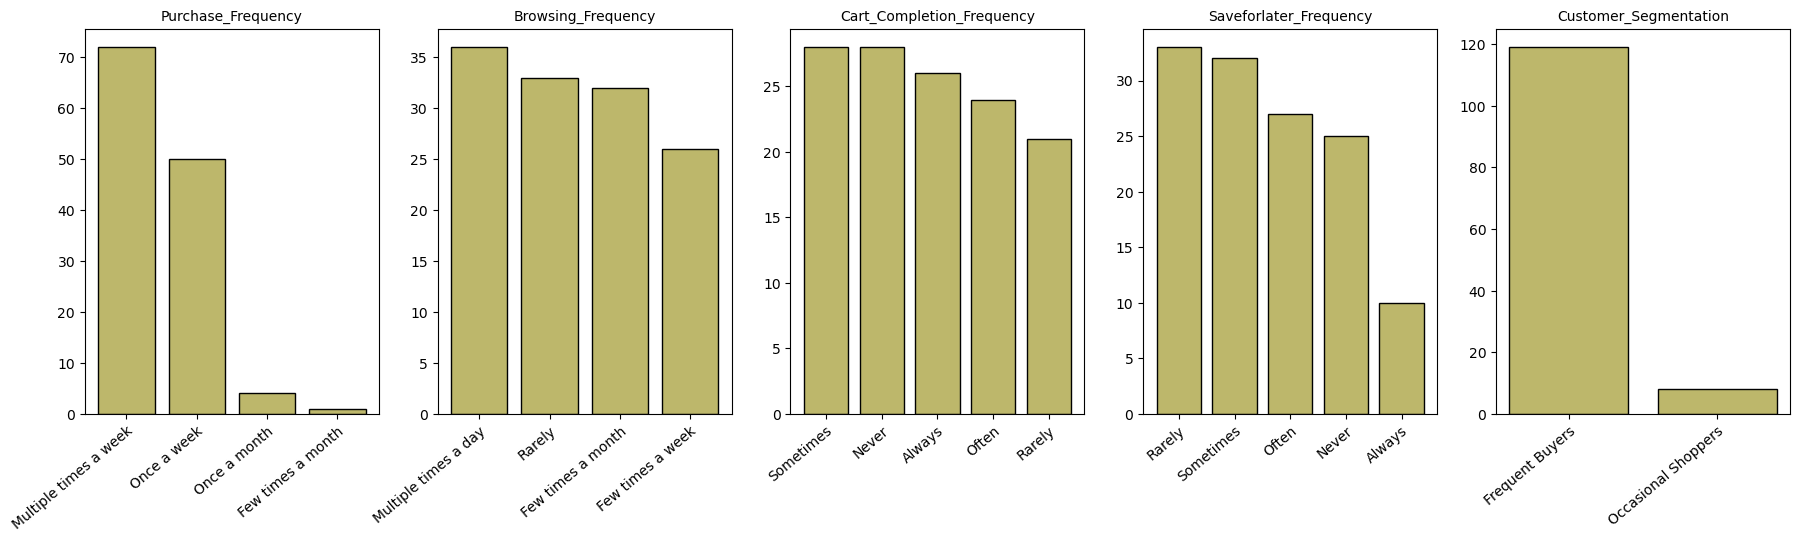

In [312]:
rows = 1
cols = 5
plot_counter = 1

data  = cluster1.loc[:, cat_cols].copy()

plt.figure(figsize=(22, 5))

for col in cat_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='darkkhaki', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

##### Inference on Cluster 1:
* This is predominantly a young group with age between 15-20 years
* Most of the users do not prefer to say their gender
* Very high shopping satisfaction
* Very high purchase frequency (multiple times a week)
* High browsing frequency (multiple times a day)
* Mixed cart completion frequency
* Mixed save for later frequency
* Predominantly Frequent buyers
* This is the most valuable and premium customer segment for Ebay: Loyal and Very Satisfied. Ebay should retain these customers by engaging them with personalized recommendations, special deals and early bird access to new launches.

#### Cluster 2 pattern and behaviour

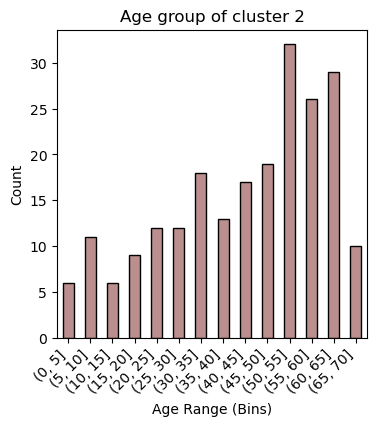

In [305]:
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
binned_counts = pd.cut(cluster2['age'], bins=bins).value_counts().sort_index()

# 4. Plot the results as a bar chart
binned_counts.plot.bar(rot=0, title='Age group of cluster 2', color= 'rosybrown', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Age Range (Bins)')
plt.ylabel('Count')
plt.show()

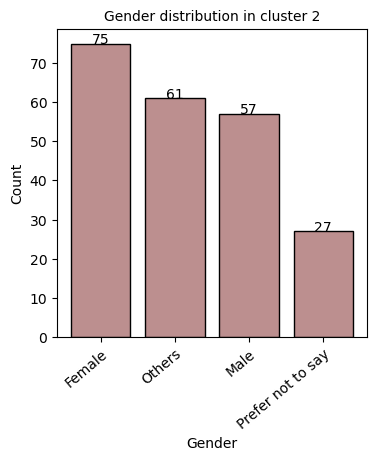

In [306]:
gender_count = cluster2['Gender'].value_counts().reset_index()

# Create the bar chart for Gender
plt.rcParams["figure.figsize"] = (4, 4)
plt.bar(gender_count['Gender'], gender_count['count'], color='rosybrown', edgecolor= 'black')

labels  = gender_count['count']

# Adding annotations
for i, value in enumerate(labels):
    plt.text(i, value, round(value), ha='center')

plt.xticks(rotation=40, ha='right', rotation_mode='anchor')

# Add labels and a title
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender distribution in cluster 2', fontsize=10)

# Display the plot
plt.show()    

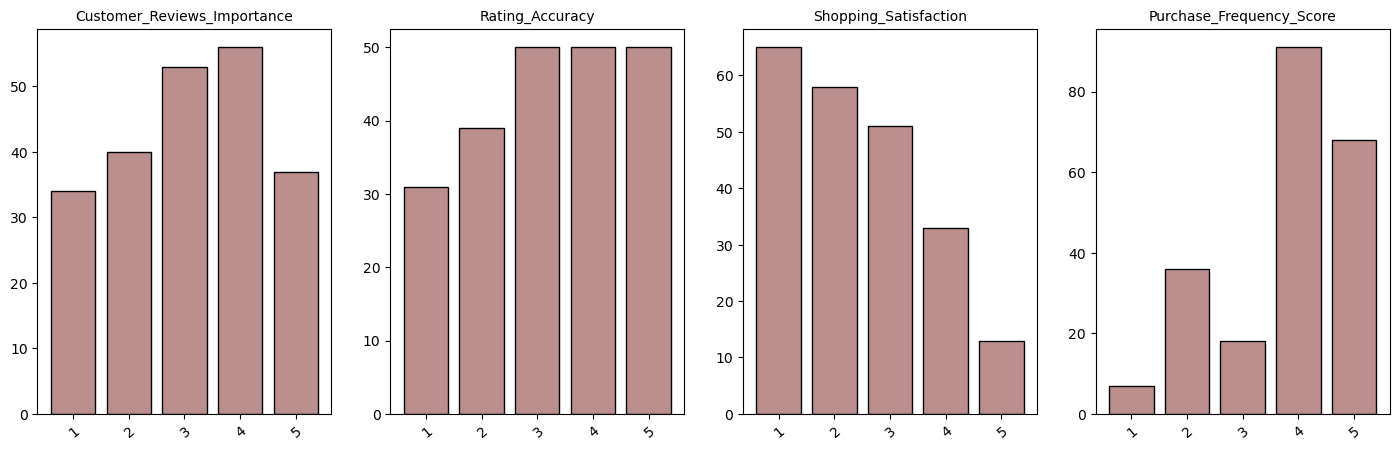

In [307]:
rows = 1
cols = 5
plot_counter = 1

data  = cluster2.loc[:, num_cols].copy()

plt.figure(figsize=(22, 5))

for col in num_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='rosybrown', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

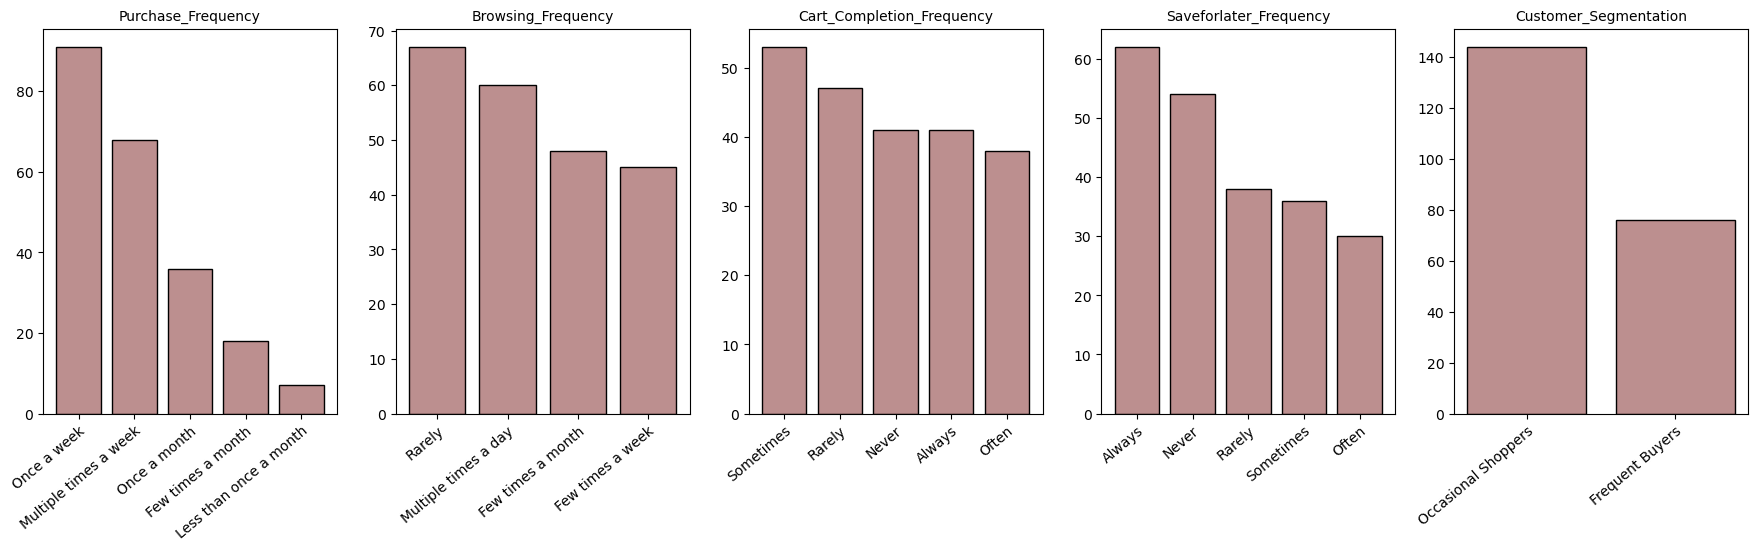

In [308]:
rows = 1
cols = 5
plot_counter = 1

data  = cluster2.loc[:, cat_cols].copy()

plt.figure(figsize=(22, 5))

for col in cat_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='rosybrown', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

##### Inference on Cluster 2:
* Predominantly middle aged to senior customers in age group: 50-55 yrs, 55-60 yrs, 60-65 yrs
* Most of the users are females
* Low shopping satisfaction
* High purchase frequency (Once a week)
* Mixed browsing frequency 
* Mixed cart completion frequency
* Most of them like to save their cart items for later
* Predominantly Occasional shoppers
* A valuable customer segment for Ebay where a lot of improvements can be done to convert the customer segment to loyal

#### Cluster 3 pattern and behaviour

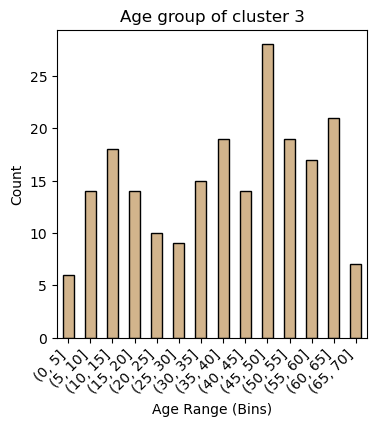

In [301]:
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
binned_counts = pd.cut(cluster3['age'], bins=bins).value_counts().sort_index()

# 4. Plot the results as a bar chart
binned_counts.plot.bar(rot=0, title='Age group of cluster 3', color= 'tan', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Age Range (Bins)')
plt.ylabel('Count')
plt.show()

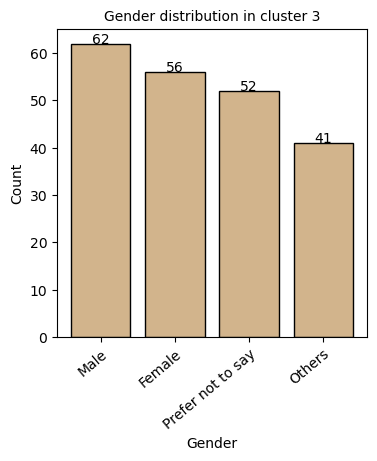

In [302]:
gender_count = cluster3['Gender'].value_counts().reset_index()

# Create the bar chart for Gender
plt.rcParams["figure.figsize"] = (4, 4)
plt.bar(gender_count['Gender'], gender_count['count'], color='tan', edgecolor= 'black')

labels  = gender_count['count']

# Adding annotations
for i, value in enumerate(labels):
    plt.text(i, value, round(value), ha='center')

plt.xticks(rotation=40, ha='right', rotation_mode='anchor')

# Add labels and a title
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender distribution in cluster 3', fontsize=10)

# Display the plot
plt.show()    

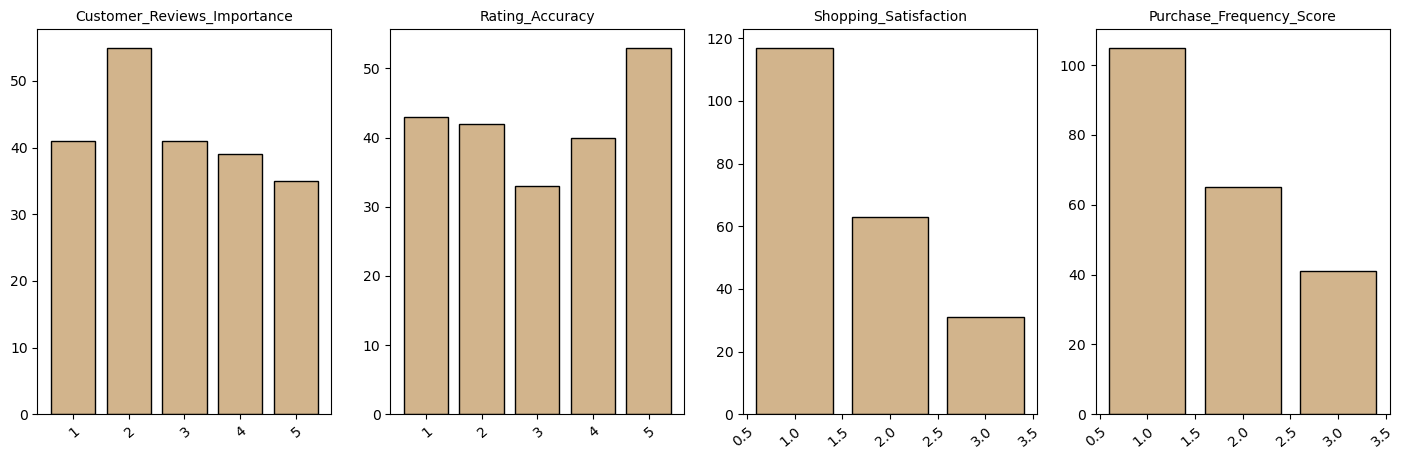

In [303]:
rows = 1
cols = 5
plot_counter = 1

data  = cluster3.loc[:, num_cols].copy()

plt.figure(figsize=(22, 5))

for col in num_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='tan', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

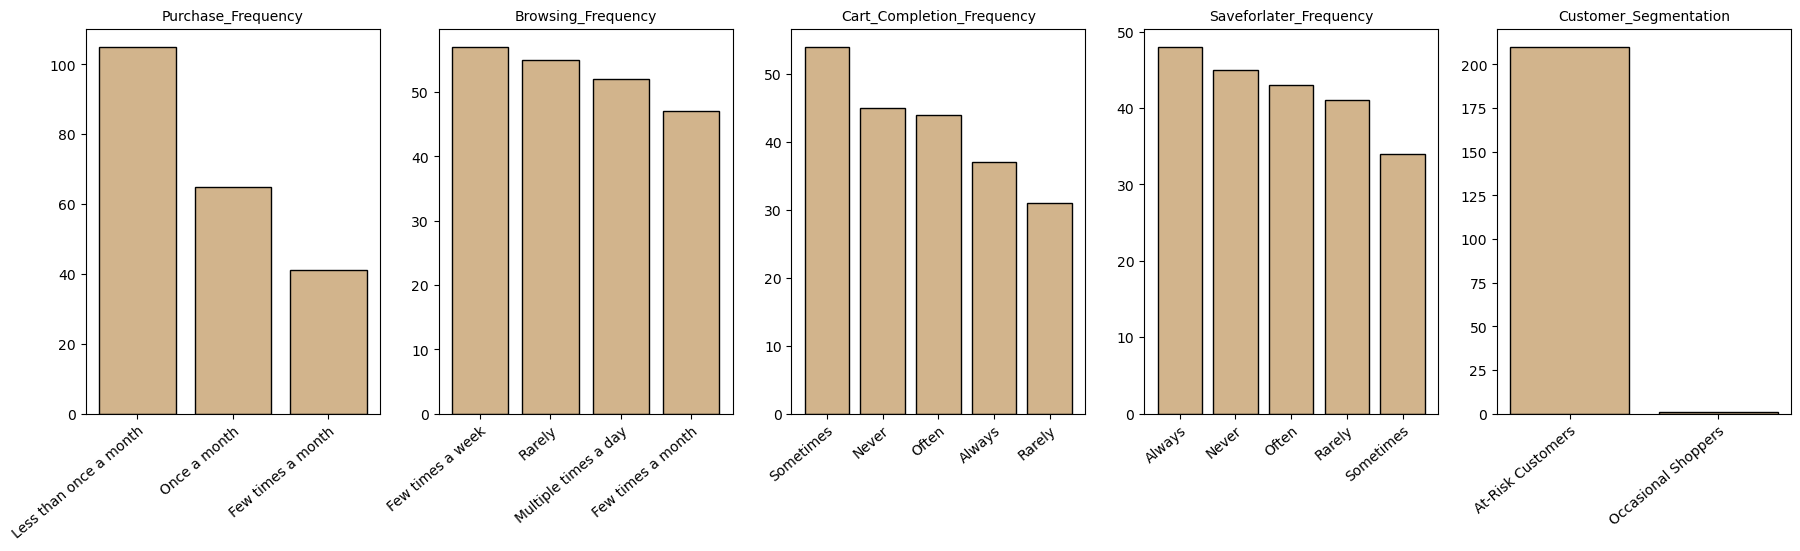

In [304]:
rows = 1
cols = 5
plot_counter = 1

data  = cluster3.loc[:, cat_cols].copy()

plt.figure(figsize=(22, 5))

for col in cat_cols:
    # Specify the subplot position (rows, columns, plot number)
    plt.subplot(rows, cols, plot_counter)
    dt = data[col].value_counts().reset_index(name='Count')
    plt.bar(dt[col], dt['Count'], color='tan', edgecolor ='black')
    plt.xticks(rotation=40, ha='right', rotation_mode='anchor')
    plt.title(f"{col}", fontsize=10)
    plot_counter += 1 # Increment the counter

##### Inference on Cluster 3:
* Predominantly middle aged customers of age group 45-50 years
* Most of the users are males
* Very low shopping satisfaction
* Very low purchase frequency (Less thn once a month)
* High browsing frequency (Few times a week)
* Mixed cart completion frequency
* Most of them like to save their cart items for later
* At-risk customers
* This is the most risky customer segment fpr Ebay. These users do not purchase even though they browse frequently. Ebay has to come up with a strong strategy in order to retain this customer segment.

### Task 4: Recommendation and Review Insights 

#### Examine the relationship between recommendation helpfulness and shopping satisfaction. 

In [194]:
data = df_final[['Recommendation_Helpfulness', 'Shopping_Satisfaction']]

# Compute the correlation matrix
corr_matrix = data.corr(method='spearman')

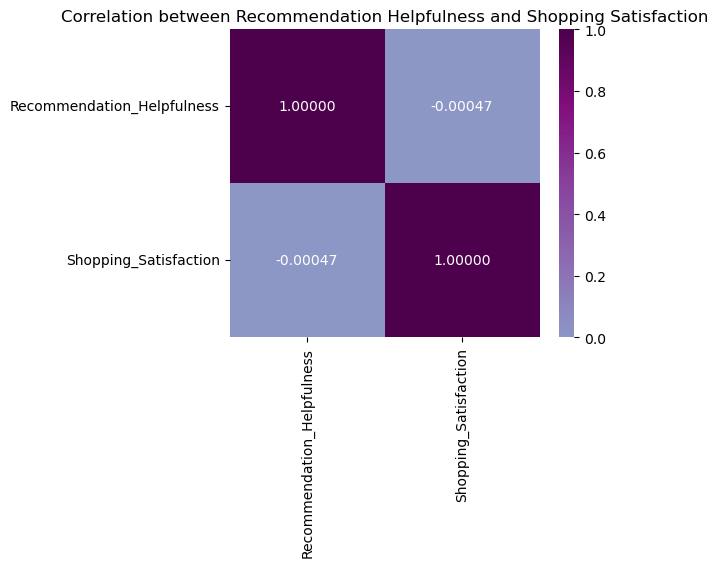

In [318]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='BuPu',
    center=0,
    fmt='.5f'
)
plt.title('Correlation between Recommendation Helpfulness and Shopping Satisfaction')
plt.show()

##### Inference:
* The Spearman's correlation coefficient between recommendation helpfulness and shopping satisfaction is -0.00047, which is almost 0.
This says that there is no meaningful correlation between these two features.

#### Evaluate how review reliability and helpfulness impact overall ratings. 

In [ ]:
# Create a new column by combining Rating_Accuracy and Shopping_Satisfaction which will represent overall rating

In [376]:
df_final['Overall_Rating'] = df_final['Rating_Accuracy'] + df_final['Shopping_Satisfaction']

In [377]:
data  = df_final[['Review_Reliability', 'Review_Helpfulness', 'Overall_Rating']]

# Compute the correlation matrix
corr_matrix = data.corr(method='spearman')

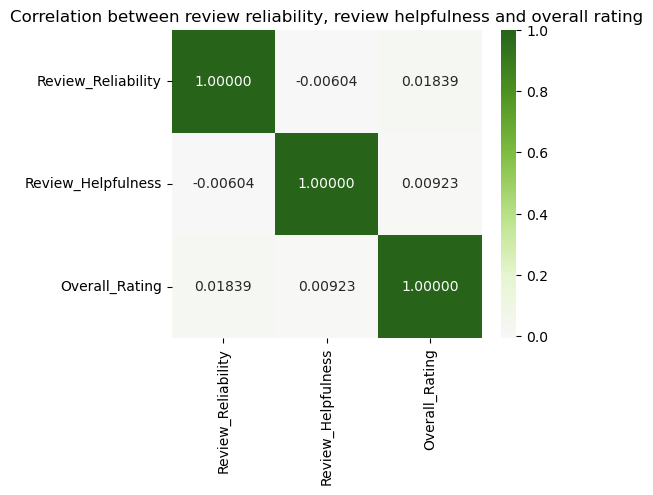

In [378]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='PiYG',
    center=0,
    fmt='.5f'
)
plt.title('Correlation between review reliability, review helpfulness and overall rating')
plt.show()

##### Inference:
The correlation coefficient between Overall rating and Review_Reliability/ Review_Helpfulness shows that there is almost no relationship between these factors.

#### Identify trends in how often customers engage with or trust personalized recommendations.

In [380]:
data = df['Recommendation_Helpfulness'].value_counts().reset_index(name='Count')

# Calculate the percentage of the total
data['Percentage'] = (data['Count'] / data['Count'].sum()) * 100
data

,Recommendation_Helpfulness,Count,Percentage
0,No,276,34.500
1,Yes,265,33.125
2,Sometimes,259,32.375


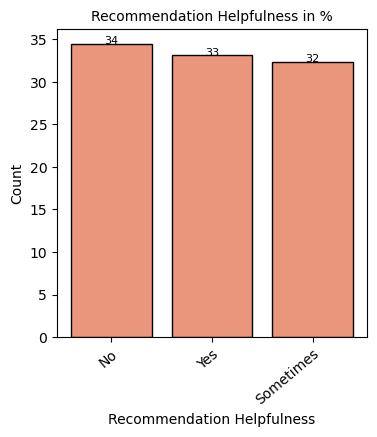

In [381]:
plt.rcParams["figure.figsize"] = (4, 4)
plt.bar(data['Recommendation_Helpfulness'], data['Percentage'], color='darksalmon', edgecolor= 'black')

labels  = data['Percentage']

# Adding annotations
for i, value in enumerate(labels):
    plt.text(i, value, round(value), ha='center', fontsize=8)

# Add labels and a title
plt.xlabel('Recommendation Helpfulness')
plt.ylabel('Count')
plt.title('Recommendation Helpfulness in %', fontsize=10)
plt.xticks(rotation=40, ha='right', rotation_mode='anchor')

# Display the plot
plt.show()    

##### Inference:
* 34% of users do not find the recommendations helpful.
* 33% of users find the recommendations helpful.
* 32% of users sometimes find the recommendations helpful.

If we consider the total of "Yes" and "Sometimes" together, 65% of the users find thre recommendations helpful (if not always). So, we can say the trust in recommendations is moderate.

#### Suggest actionable insights for improving eBay’s recommendation system

* Increase relevance of recommendations <br>
Increased recommendation is not resulting in increased shopping satisfaction. This would be because the recommendations are random and not very personalized. Users should find the recommendations useful and relevant for their taste. <br>

* Improve trust in recommendations <br>
Recommendation should come with an explanation on why it is getting recommended such as  “Product pairs well with…”, “Customer who bought this also bought.. ”, “Similar product to..” (cross-sell, upsell and bundles) and ‘New lunches”. Customers trust recommendations when it comes with an explanation on why they are seeing it rather than seeing a random recommendation. <br>


* Recommendations based on engagement <br>
•	High-engagement users: <br>
o	Show personalized bundles, cross-sell, and upsell suggestions. <br>
•	Low-engagement users: <br>
o	Show fewer but highly relevant recommendations (e.g., top-rated or trending). <br>
•	New users: <br>
o	Use popularity-based or category-based recommendations. <br>


* Recommendations based on reviews <br>
Users feel confident when they get recommendations with higher reviews and user ratings. Suggesting low rated products will result in user losing confidence in the recommendation. <br>
•	Prioritize items with: <br>
o	High review reliability <br>
o	Helpful review votes <br>


* Placement of recommendations <br>
When and were the recommendation appears matters a lot. <br>
•	Show recommendations: <br>
o	After cart actions (“Customers also bought”) <br>
o	During comparison browsing, not at checkout <br>
•	Avoid aggressive recommendation pop-ups during payment flow. <br>

* Continuously Measure Recommendation Effectiveness <br>
Insight: Current system impact is weak and needs refinement. <br>
•	Track: <br>
o	Recommendation click-through rate (CTR) <br>
o	Conversion from recommended items <br>
o	Satisfaction by recommendation interaction <br>
•	Run A/B tests on relevance logic and explanation text. <br>

* Allow User Control <br>
Partial trust suggests users want more control. <br>
•	Let users: <br>
o	Hide irrelevant recommendations <br>
o	Choose preferred categories <br>
o	Provide quick feedback (“Not relevant”) <br>


* Final Takeaway <br>
To improve eBay’s recommendation system: <br>
Focus less on showing more recommendations and more on showing the right ones, at the right time, with clear reasoning. <br>
This approach directly addresses the observed gaps in trust, engagement, and satisfaction while being highly actionable. <br>

#### Task 5: Visualization and Reporting

Create attractive visualizations (bar charts, heatmaps, pie charts) for: 
* Purchase categories 
* Browsing frequency distribution 
* Satisfaction levels 
* Correlation between recommendation usefulness and satisfaction 

In [327]:
data = df_purchase_categories.sum().reset_index(name='Count')
data['Percentage'] = (data['Count']/data['Count'].sum())*100
data = data.rename(columns={'index':'Purchase_Category'})
data

,Purchase_Category,Count,Percentage
0,Groceries and Gourmet Food,366,17.897311
1,Home and Kitchen,421,20.586797
2,Beauty and Personal Care,418,20.440098
3,Clothing and Fashion,450,22.004890
4,others,390,19.070905


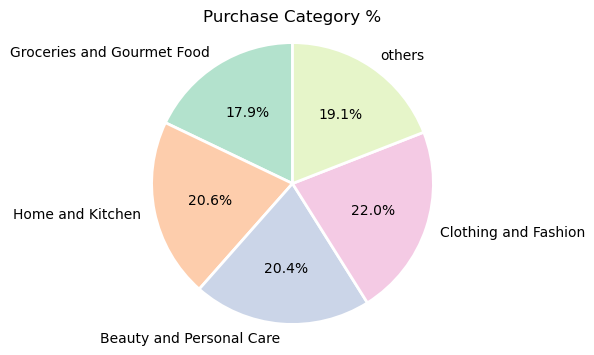

In [328]:
# Create the pie chart
plt.pie(data['Percentage'], labels=data['Purchase_Category'], 
        autopct='%1.1f%%', 
        startangle=90, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        colors=plt.cm.Pastel2.colors)


plt.axis('equal') 
plt.title('Purchase Category %')
plt.show()

In [335]:
data = df['Browsing_Frequency'].value_counts().reset_index(name='Count')
data['Percentage'] = (data['Count']/data['Count'].sum())*100
data = data.rename(columns={'index':'Browsing_Frequency'})
data

,Browsing_Frequency,Count,Percentage
0,Rarely,210,26.250
1,Multiple times a day,199,24.875
2,Few times a week,199,24.875
3,Few times a month,192,24.000


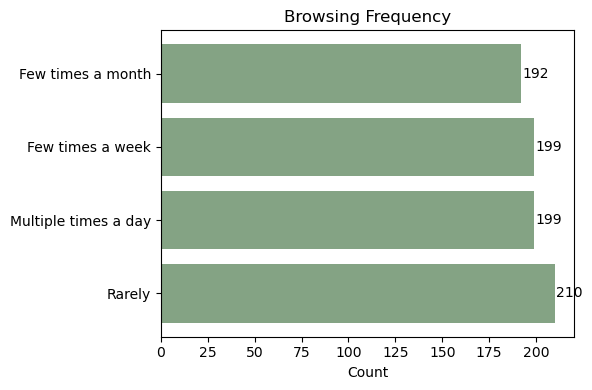

In [342]:
categories = data['Browsing_Frequency']
values = data['Count']

color = (0.2, # redness
         0.4, # greenness
         0.2, # blueness
         0.6 # transparency
         ) 

# Create horizontal bar chart
plt.figure(figsize=(6, 4))
bars = plt.barh(categories, values, color=color)

# Add labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,                     # position slightly after bar
        bar.get_y() + bar.get_height()/2,
        f'{width}',
        va='center'
    )

# Labels and title
plt.xlabel('Count')
plt.title('Browsing Frequency')

plt.tight_layout()
plt.show()

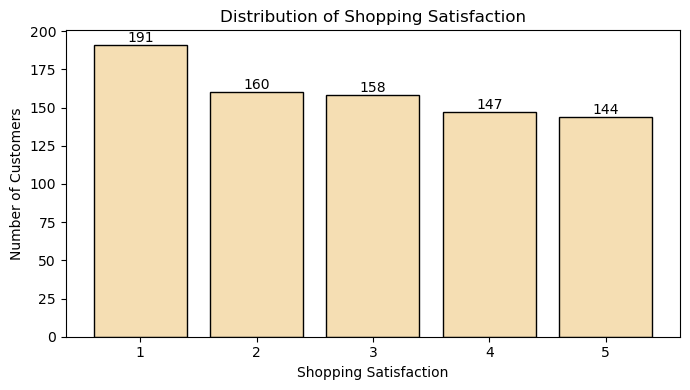

In [343]:
# Count Shopping Satisfaction ratings
satisfaction_counts = df['Shopping_Satisfaction'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(7, 4))
bars = plt.bar(
    satisfaction_counts.index,
    satisfaction_counts.values,
    color='wheat', edgecolor= 'black'
)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

# Labels and title
plt.xlabel('Shopping Satisfaction')
plt.ylabel('Number of Customers')
plt.title('Distribution of Shopping Satisfaction')

plt.tight_layout()
plt.show()

In [253]:
data = df_final[['Recommendation_Helpfulness', 'Shopping_Satisfaction']]

# Compute the correlation matrix
corr_matrix = data.corr(method='spearman')

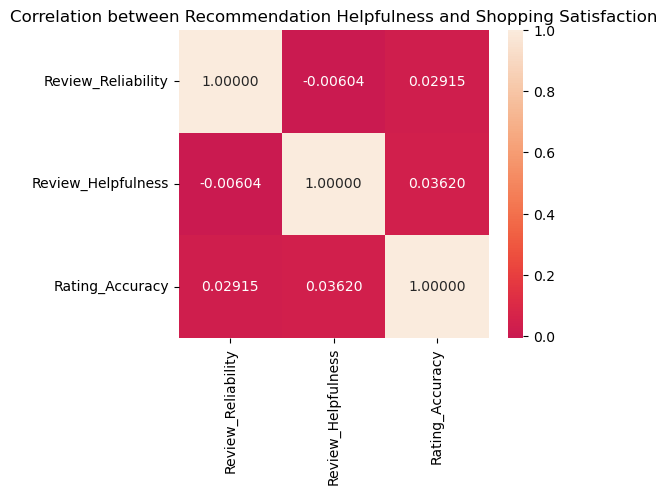

In [345]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='rocket',
    center=0,
    fmt='.5f'
)
plt.title('Correlation between Recommendation Helpfulness and Shopping Satisfaction')
plt.show()

##### Purchase Categories

* Insight <br>
•	Clothing & Fashion, Home & Kitchen, and Beauty & Personal Care dominate purchases. <br>
•	Grocery-related purchases are comparatively lower. <br>

* Interpretation <br>
•	Customers primarily use eBay for lifestyle and personal-use products rather than essentials. <br>
•	Category-focused recommendations in these dominant segments can deliver higher impact.

##### Browsing Frequency Distribution

* Insight <br>
•	Browsing behavior is evenly distributed across all frequency levels. <br>
•	No single browsing pattern dominates the user base. <br>
<br>
 * Interpretation <br>
•	eBay attracts both frequent and occasional users. <br>
•	Recommendation strategies should adapt dynamically to user activity level.

##### Shopping Satisfaction Levels
* Insight <br>
•	Satisfaction scores are moderately distributed across all levels. <br>
•	Slightly higher counts at lower satisfaction ratings (1–2). <br>

* Interpretation <br>
•	Overall satisfaction is mixed, not strongly positive. <br>
•	Indicates scope for improvement in user experience, delivery, pricing, or relevance.


##### Recommendation Helpfulness vs Satisfaction (Correlation Heatmap)

* Insight <br>
•	Spearman correlation ≈ 0.00 (no meaningful relationship). <br>
<br>
 
* Interpretation <br>
•	Recommendation usefulness currently has no measurable impact on satisfaction. <br>
•	Suggests recommendations may lack relevance, timing, or trustworthiness.

*  Personalized recommendations are present but underperforming.
*  Satisfaction is driven by factors beyond recommendations, such as product quality or service.
*  Improving relevance, explainability, and contextual delivery of recommendations is critical.
<br><br>
eBay’s recommendation system currently plays a supporting role, not a decisive one, in shaping customer satisfaction. 
Strategic refinement—not increased frequency—is needed to improve its effectiveness.

In [1]:
# Link to video presentation
from IPython.display import display, HTML

link_html = '<a href="https://www.loom.com/share/ba4d213af68045999ba1f962b7934138">Presentation</a>'

# Display the HTML object
display(HTML(link_html))